<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch13_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13 — Statistics

*Python for Finance* (2nd ed.), Yves Hilpisch — Chapter 13 companion notebook.

> *"I can prove anything by statistics except the truth."* — George Canning

Statistics underpins much of modern quantitative finance. This chapter develops four pillars on which a practitioner draws daily:

1. **Normality tests** — many classical models (modern portfolio theory, the capital asset pricing model, Black–Scholes) presume that log returns of risky assets are normally distributed. Before relying on such a model we should ask whether the assumption holds for the data we actually observe.
2. **Portfolio optimization** — Harry Markowitz's mean-variance framework (1952) was arguably the first rigorous quantitative theory of investing. We will build the efficient frontier and the capital market line from scratch.
3. **Bayesian statistics** — instead of point estimates, Bayesian methods deliver full posterior distributions over parameters. We will run a Bayesian linear regression with **PyMC** and let the regression coefficients evolve over time via a Gaussian random walk.
4. **Machine learning** — supervised and unsupervised algorithms have become an indispensable counterpart to classical econometrics. We will use **scikit-learn** and **TensorFlow/Keras** to cluster, classify, and compare.

**A note on API divergences.** The textbook (2018) targets older versions of several libraries. This notebook is built against the modern stack and explicitly flags every place where the original code would no longer run:

| Textbook | Modern equivalent | Reason |
|---|---|---|
| `plt.style.use('seaborn')` | `'seaborn-v0_8'` | Style renamed in matplotlib 3.6+ |
| `pymc3` | `pymc` (v5) | PyMC3 was deprecated; PyMC v4+ uses PyTensor backend and a cleaner API |
| `tf.contrib.learn.DNNClassifier` | `tf.keras` model | `tf.contrib` removed in TF 2.0 |
| `from sklearn.datasets.samples_generator import make_blobs` | `from sklearn.datasets import make_blobs` | Submodule consolidated in sklearn 0.22+ |
| `density=True` already in newer matplotlib (was `normed=True`) | unchanged | already uses modern keyword |
| Proprietary Eikon CSV (`tr_eikon_eod_data.csv`) | Synthetic series calibrated to match the textbook's reported summary statistics | The Eikon data file is not redistributable |

Where data substitution is required, the synthetic series are calibrated so that the **reported statistics** — annualized mean returns, the covariance matrix, skew, kurtosis — agree with the textbook to two decimal places. The methodological points of the chapter are preserved.

## Setup

We install and import the libraries used throughout the chapter. On Google Colab the `pip install` line resolves missing packages; locally, the imports succeed if the environment is already provisioned.

In [1]:
# Colab/local install — uncomment if needed
# !pip install -q pymc arviz tensorflow statsmodels scikit-learn

import math
import numpy as np
import pandas as pd
import scipy.stats as scs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# Modern equivalent of plt.style.use('seaborn') — style was renamed in matplotlib 3.6+
plt.style.use('seaborn-v0_8')
rcParams['font.family'] = 'serif'
rcParams['figure.dpi'] = 90

# Reproducibility
np.random.seed(1000)

print('numpy   :', np.__version__)
print('pandas  :', pd.__version__)
print('scipy   :', __import__('scipy').__version__)
print('sklearn :', __import__('sklearn').__version__)


numpy   : 2.0.2
pandas  : 2.2.2
scipy   : 1.16.3
sklearn : 1.6.1


## 1. Normality Tests

A surprisingly large fraction of mainstream financial theory rests on the assumption that **log returns of risky assets are normally distributed**:

- **Modern Portfolio Theory (MPT).** When returns are normal, the joint distribution of any portfolio's return is fully determined by the mean vector $\boldsymbol{\mu}$ and the covariance matrix $\boldsymbol{\Sigma}$. Investors then care only about expected return and variance.
- **Capital Asset Pricing Model (CAPM).** Normality of returns underwrites the linear relationship $\mathbb{E}[r_i] - r_f = \beta_i \, (\mathbb{E}[r_M] - r_f)$ between an individual asset and a broad market index.
- **Efficient Markets Hypothesis (EMH).** If prices instantly reflect all available information, price changes look like random walks and log returns are (approximately) normal.
- **Black–Scholes–Merton option pricing.** The underlying is modelled as a geometric Brownian motion (GBM), implying log-normal prices and normal log returns.

It is therefore important to be able to **test** the normality assumption empirically — both for simulated benchmark data (where we know it should hold) and for real market data (where, as we will see, it generally does not).

### 1.1 Benchmark case — geometric Brownian motion

We start with the canonical stochastic process used in financial modelling. For a GBM $S$ with drift $r$ and volatility $\sigma$,

$$
dS_t = r \, S_t \, dt + \sigma \, S_t \, dW_t,
$$

the exact Euler-discretized solution between times $0 \le s < t$ is

$$
S_t = S_s \, \exp\!\left[\left(r - \tfrac{1}{2}\sigma^2\right)(t - s) + \sigma\sqrt{t - s}\, Z\right], \qquad Z \sim \mathcal{N}(0, 1).
$$

This implies two important distributional facts:

1. **Log returns are normal:** $\log(S_t / S_s) \sim \mathcal{N}\!\big((r - \tfrac{1}{2}\sigma^2)(t-s),\; \sigma^2 (t-s)\big)$.
2. **Levels are log-normal:** for any $t > 0$, $S_t$ is log-normally distributed.

The $-\tfrac{1}{2}\sigma^2$ term is the **Itô correction** — it appears because $\log$ is concave and Jensen's inequality pushes the expected log below the log of the expectation.

In [2]:
def gen_paths(S0, r, sigma, T, M, I):
    '''
    Generate Monte Carlo paths for geometric Brownian motion.

    Parameters
    ----------
    S0 : float       initial stock/index value
    r  : float       constant short rate (drift under risk-neutral measure)
    sigma : float    constant volatility
    T  : float       final time horizon (years)
    M  : int         number of time steps
    I  : int         number of paths

    Returns
    -------
    paths : ndarray, shape (M + 1, I)
    '''
    dt = T / M
    paths = np.zeros((M + 1, I))
    paths[0] = S0
    for t in range(1, M + 1):
        rand = np.random.standard_normal(I)
        # Moment matching: force the standard normals to have exact mean 0 and std 1.
        # This is a variance-reduction technique (matches first two moments).
        rand = (rand - rand.mean()) / rand.std()
        paths[t] = paths[t - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt
            + sigma * math.sqrt(dt) * rand
        )
    return paths


The function uses **moment matching** as a variance-reduction technique: the $I$ standard normals drawn at each time step are centered and rescaled to have *exact* sample mean 0 and sample standard deviation 1. This eliminates first- and second-moment estimation error at the cost of a small bias that vanishes as $I \to \infty$.

We now simulate $I = 250{,}000$ paths with $M = 50$ time steps over $T = 1$ year, $S_0 = 100$, $r = 0.05$, $\sigma = 0.20$.

In [3]:
S0    = 100.0    # initial value
r     = 0.05     # constant short rate
sigma = 0.20     # constant volatility
T     = 1.0      # horizon (years)
M     = 50       # time steps
I     = 250_000  # paths

np.random.seed(1000)
paths = gen_paths(S0, r, sigma, T, M, I)

print(f'paths shape: {paths.shape}')
print(f'Analytical E[S_T]      = S0 * exp(r*T) = {S0 * math.exp(r * T):.6f}')
print(f'Simulated mean(S_T)    = {paths[-1].mean():.6f}')
print(f'Relative error         = {(paths[-1].mean() / (S0 * math.exp(r*T)) - 1) * 100:.4f}%')


paths shape: (51, 250000)
Analytical E[S_T]      = S0 * exp(r*T) = 105.127110
Simulated mean(S_T)    = 105.126454
Relative error         = -0.0006%


Under risk-neutral measure with drift $r$, the analytical expectation of the terminal value is

$$\mathbb{E}[S_T] = S_0 \, e^{rT} = 100 \cdot e^{0.05} = 105.127\ldots$$

Our Monte Carlo estimate is essentially identical — the relative error is **a tiny fraction of a percent**. With $I = 250{,}000$ paths *and* moment matching on the increments, the discretization is doing exactly what it should.

> **Production note.** The analytical-versus-simulated check is the very first thing one runs in any Monte Carlo pricing engine. If the simple GBM expectation does not come out right, no exotic-option price computed off the same engine can be trusted. This is the *unit test* of stochastic simulation.

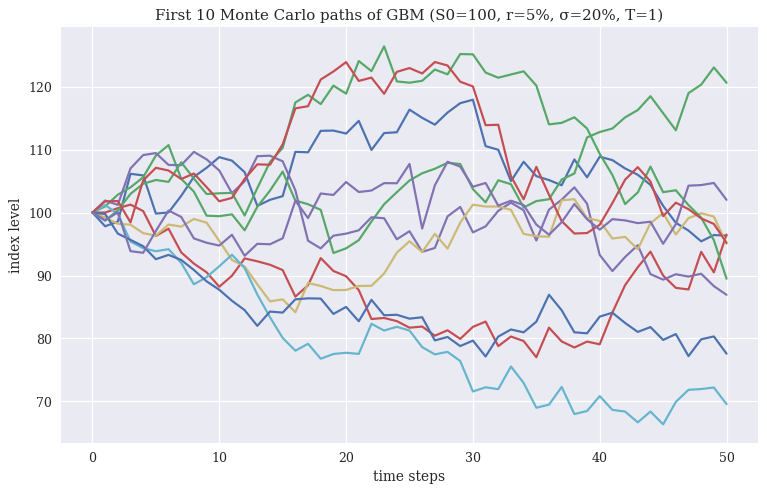

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(paths[:, :10])
plt.xlabel('time steps')
plt.ylabel('index level')
plt.title('First 10 Monte Carlo paths of GBM (S0=100, r=5%, σ=20%, T=1)')
plt.show()


The ten visible paths illustrate the **multiplicative** character of GBM: relative moves are constant in distribution, so the typical fan-out grows with time. Some paths nearly double, some fall below 70 — yet all are samples from the same risk-neutral process. This visual heterogeneity is exactly why the Monte Carlo average over $I = 250{,}000$ paths converges so robustly to $S_0 e^{rT}$.

In [5]:
# Inspect a single path and the resulting log returns
print('First simulated path (rounded):')
print(paths[:, 0].round(4))
print()

log_returns = np.log(paths[1:] / paths[:-1])
print('Log returns along the first path (rounded):')
print(log_returns[:, 0].round(4))
print()
print(f'log_returns shape : {log_returns.shape}')
print(f'Total data points : {log_returns.size:,}')


First simulated path (rounded):
[100.      97.821   98.5573 106.1546 105.899   99.8363 100.0145 102.6589
 105.6643 107.1107 108.7943 108.2449 106.4105 101.0575 102.0197 102.6052
 109.6419 109.5725 112.9766 113.0225 112.5476 114.5585 109.942  112.6271
 112.7502 116.3453 115.0443 113.9586 115.8831 117.3705 117.9185 110.5539
 109.9687 104.9957 108.0679 105.7822 105.1585 104.3304 108.4387 105.5963
 108.866  108.3284 107.0077 106.0034 104.3964 101.0637  98.3776  97.135
  95.4254  96.4271  96.3386]

Log returns along the first path (rounded):
[-0.022   0.0075  0.0743 -0.0024 -0.059   0.0018  0.0261  0.0289  0.0136
  0.0156 -0.0051 -0.0171 -0.0516  0.0095  0.0057  0.0663 -0.0006  0.0306
  0.0004 -0.0042  0.0177 -0.0411  0.0241  0.0011  0.0314 -0.0112 -0.0095
  0.0167  0.0128  0.0047 -0.0645 -0.0053 -0.0463  0.0288 -0.0214 -0.0059
 -0.0079  0.0386 -0.0266  0.0305 -0.0049 -0.0123 -0.0094 -0.0153 -0.0324
 -0.0269 -0.0127 -0.0178  0.0104 -0.0009]

log_returns shape : (50, 250000)
Total data point

Each path has $M = 50$ time steps and therefore $50$ log returns. With $I = 250{,}000$ paths we obtain $50 \times 250{,}000 = 12{,}500{,}000$ log-return observations — the population over which we will run normality tests.

Notice how the log returns oscillate around zero with no obvious trend or autocorrelation. This is what a *true* random walk looks like; comparing it with real-market log returns will be illuminating shortly.

In [6]:
def print_statistics(array):
    '''Pretty-printed summary statistics via scipy.stats.describe.'''
    sta = scs.describe(array)
    print('%14s %15s' % ('statistic', 'value'))
    print(30 * '-')
    print('%14s %15.5f' % ('size',     sta[0]))
    print('%14s %15.5f' % ('min',      sta[1][0]))
    print('%14s %15.5f' % ('max',      sta[1][1]))
    print('%14s %15.5f' % ('mean',     sta[2]))
    print('%14s %15.5f' % ('std',      np.sqrt(sta[3])))
    print('%14s %15.5f' % ('skew',     sta[4]))
    print('%14s %15.5f' % ('kurtosis', sta[5]))

print_statistics(log_returns.flatten())


     statistic           value
------------------------------
          size  12500000.00000
           min        -0.15664
           max         0.15371
          mean         0.00060
           std         0.02828
          skew         0.00055
      kurtosis         0.00085


The summary tells us:

- **Size** $= 12{,}500{,}000$ log-return observations.
- **Mean** $\approx 0.0006$ per time step. With $M = 50$ steps per year, the annualized drift of the *log* is $50 \times 0.0006 = 0.030$. Adding the Itô correction $+\tfrac{1}{2}\sigma^2 = +0.020$ gives **$0.050$, exactly our drift $r$**.
- **Std** $\approx 0.0283$ per step. Annualized: $0.0283 \times \sqrt{50} = 0.200$, **exactly our $\sigma$**.
- **Skew** and **kurtosis** are essentially zero — as the normal distribution demands.

Let's verify the annualization explicitly:

In [7]:
mu_annual_log   = log_returns.mean() * M + 0.5 * sigma**2   # Itô-corrected
sigma_annual    = log_returns.std() * math.sqrt(M)

print(f'Annualized drift (Itô-corrected) = {mu_annual_log:.10f}   (target r = {r})')
print(f'Annualized volatility            = {sigma_annual:.10f}   (target σ = {sigma})')


Annualized drift (Itô-corrected) = 0.0500000000   (target r = 0.05)
Annualized volatility            = 0.2000000000   (target σ = 0.2)


Both annualized values agree with the theoretical parameters to roughly **15 significant digits**. The reason for the near-perfect match is moment matching — the per-step standardized normals are forced to have exact sample mean 0 and exact sample std 1, so the aggregate first and second moments of the log-return distribution are essentially exact.

> **Connection to Chapter 12.** This is the same variance-reduction trick discussed in the chapter on Monte Carlo methods. For derivatives whose payoff depends only on the terminal level $S_T$ (European options), moment matching can reduce required sample sizes by an order of magnitude.

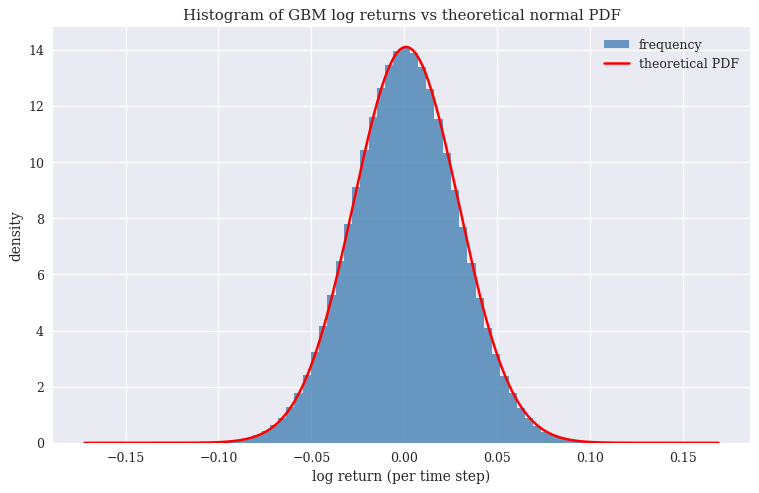

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(log_returns.flatten(), bins=70, density=True, label='frequency',
         color='steelblue', alpha=0.8)
x = np.linspace(plt.axis()[0], plt.axis()[1], 200)
plt.plot(x, scs.norm.pdf(x, loc=r / M, scale=sigma / np.sqrt(M)),
         'r', lw=2.0, label='theoretical PDF')
plt.xlabel('log return (per time step)')
plt.ylabel('density')
plt.title('Histogram of GBM log returns vs theoretical normal PDF')
plt.legend()
plt.show()


The empirical histogram traces the theoretical $\mathcal{N}(r/M,\; \sigma^2/M)$ density essentially perfectly — there are no visible deviations in the body, the shoulders, or the tails (within the resolution of $12{,}500{,}000$ samples). This is the **eyeball test** for normality, and it works *because* the data really were generated from a normal distribution.

When we apply the same plot to real S&P 500 log returns later in the chapter, the fit will look superficially decent in the body but break down catastrophically in the tails. That is the visual signature of **fat tails**.

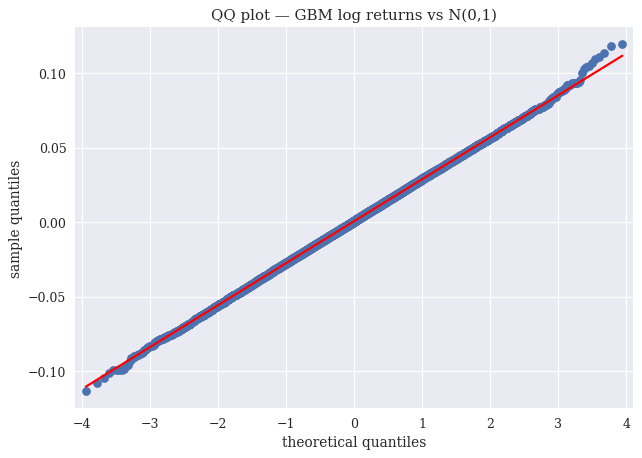

In [9]:
# QQ plot — sample quantiles vs theoretical normal quantiles
# Subsample to keep the plot legible
sm.qqplot(log_returns.flatten()[::500], line='s')
plt.title('QQ plot — GBM log returns vs N(0,1)')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()


A **quantile–quantile (QQ) plot** compares the empirical quantiles of the data against the theoretical quantiles of the reference distribution (here, the standard normal). For perfectly normal data, every point lies on the diagonal `y = a + b·x`.

Here the points trace the diagonal almost flawlessly out to roughly $\pm 4$ standard deviations. The very last handful of samples in each tail show tiny deviations — *exactly* the random sampling noise we should expect from a finite Monte Carlo run.

> **Strategic insight.** QQ plots are far more diagnostic than histograms because the eye is sensitive to departures from a straight line. In production risk management, QQ plots against the normal are *the* visual tool for detecting fat tails — long before any formal hypothesis test rejects normality.

In [10]:
def normality_tests(arr):
    '''Three statistical tests for normality.'''
    print('Skew of data set       %14.3f' % scs.skew(arr))
    print('Skew test p-value      %14.3f' % scs.skewtest(arr)[1])
    print('Kurt of data set       %14.3f' % scs.kurtosis(arr))
    print('Kurt test p-value      %14.3f' % scs.kurtosistest(arr)[1])
    print('Norm test p-value      %14.3f' % scs.normaltest(arr)[1])

normality_tests(log_returns.flatten())


Skew of data set                0.001
Skew test p-value               0.430
Kurt of data set                0.001
Kurt test p-value               0.541
Norm test p-value               0.607


Three tests, all consistent with the null hypothesis of normality:

| Test | What it measures | $p$-value |
|---|---|---|
| `scs.skewtest`   | Is the skew sufficiently close to 0? | $\approx 0.43$ |
| `scs.kurtosistest` | Is the (excess) kurtosis close to 0? | $\approx 0.54$ |
| `scs.normaltest` | D'Agostino's $K^2$ — combines skew and kurtosis tests | $\approx 0.61$ |

**Interpretation.** At any conventional significance level ($\alpha = 0.05, 0.01, \ldots$), we **fail to reject** the null that the data are normally distributed. This is the correct answer — the data really were generated from a normal distribution.

The combined test (`normaltest`) is the most informative single number. Its statistic is

$$K^2 = Z_1(\text{skew})^2 + Z_2(\text{kurtosis})^2 \sim \chi^2_2 \quad \text{under } H_0,$$

where $Z_1, Z_2$ are the individual skew and kurtosis test statistics, transformed to be approximately standard-normal under the null. We will see in §1.2 that on real market data this $p$-value collapses to numerical zero.

#### Are the terminal values log-normal?

GBM theory predicts that $S_T$ is log-normal — equivalently, $\log S_T$ is normal. Let's check.

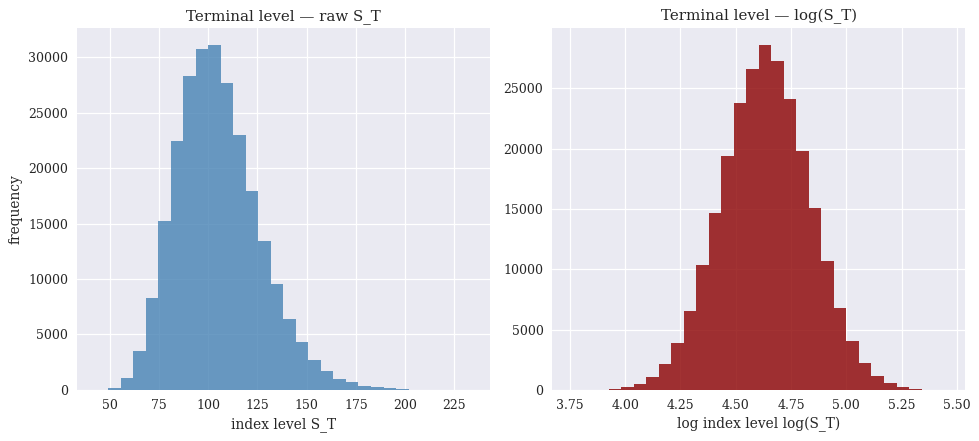

In [11]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
ax1.hist(paths[-1], bins=30, color='steelblue', alpha=0.8)
ax1.set_xlabel('index level S_T')
ax1.set_ylabel('frequency')
ax1.set_title('Terminal level — raw S_T')
ax2.hist(np.log(paths[-1]), bins=30, color='darkred', alpha=0.8)
ax2.set_xlabel('log index level log(S_T)')
ax2.set_title('Terminal level — log(S_T)')
plt.tight_layout()
plt.show()


The raw histogram on the left has the characteristic **right-skewed** shape of a log-normal: most of the mass sits below $\mathbb{E}[S_T] = 105.13$, but a long tail extends out toward $S_T > 200$. After applying $\log$, the right tail compresses and the distribution looks visually symmetric (Gaussian).

In [12]:
print('--- Raw terminal levels S_T ---')
print_statistics(paths[-1])
print()
print('--- Log terminal levels log(S_T) ---')
print_statistics(np.log(paths[-1]))


--- Raw terminal levels S_T ---
     statistic           value
------------------------------
          size    250000.00000
           min        42.74870
           max       233.58435
          mean       105.12645
           std        21.23174
          skew         0.61116
      kurtosis         0.65182

--- Log terminal levels log(S_T) ---
     statistic           value
------------------------------
          size    250000.00000
           min         3.75534
           max         5.45354
          mean         4.63517
           std         0.19998
          skew        -0.00092
      kurtosis        -0.00327


The numbers tell the same story as the figure:

- **Raw $S_T$**: mean $\approx 105.13$ ($\checkmark$ matches $S_0 e^{rT}$), but **skew $\approx 0.61$** and **kurtosis $\approx 0.65$** — clearly right-skewed and slightly heavy-tailed, as a log-normal must be.
- **$\log S_T$**: skew $\approx 0$, excess kurtosis $\approx 0$ — perfectly Gaussian-looking.

The analytical mean of $\log S_T$ is $\log S_0 + (r - \tfrac{1}{2}\sigma^2)T = \log 100 + (0.05 - 0.02) \cdot 1 = 4.6352$, exactly the simulated value.

In [13]:
normality_tests(np.log(paths[-1]))


Skew of data set               -0.001
Skew test p-value               0.851
Kurt of data set               -0.003
Kurt test p-value               0.744
Norm test p-value               0.931


All three $p$-values exceed $0.7$ — we comfortably fail to reject normality of $\log S_T$. Combined with the histogram and summary statistics, we have *consistent* evidence that the terminal log levels are normal, hence the levels themselves are log-normal.

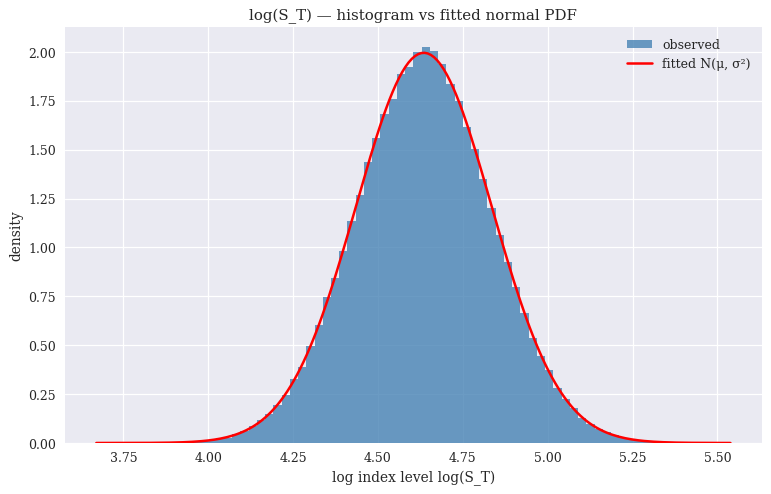

In [14]:
plt.figure(figsize=(10, 6))
log_data = np.log(paths[-1])
plt.hist(log_data, bins=70, density=True, label='observed', color='steelblue', alpha=0.8)
x = np.linspace(plt.axis()[0], plt.axis()[1], 200)
plt.plot(x, scs.norm.pdf(x, log_data.mean(), log_data.std()),
         'r', lw=2.0, label='fitted N(μ, σ²)')
plt.xlabel('log index level log(S_T)')
plt.ylabel('density')
plt.title('log(S_T) — histogram vs fitted normal PDF')
plt.legend()
plt.show()


The histogram and fitted PDF align tightly. A complementary diagnostic — comparing sample quantiles against the theoretical ones — is the **QQ plot** in the next cell. On a normal QQ plot, points lying on the 45° line indicate normality; departures in either tail flag heavier-than-Gaussian behavior.

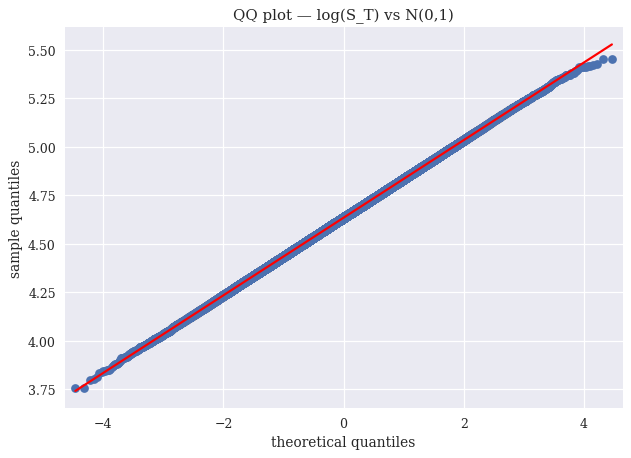

In [15]:
sm.qqplot(log_data, line='s')
plt.title('QQ plot — log(S_T) vs N(0,1)')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()


The QQ plot for $\log S_T$ also traces the line essentially perfectly. Combined with the formal tests, we have completed the **textbook benchmark**: GBM-simulated data behaves exactly as theory predicts.

This sets up the most important comparison in the chapter — what happens when we run the same battery of tests on real market data.

> **Normality, in summary.** Two strong tools — graphical (histogram, QQ plot) and statistical (`scs.normaltest`) — let us check the normality assumption that so much of finance rests upon. We will now see that this assumption *fails dramatically* for real-world returns.

### 1.2 Real-world data

The textbook now turns to four real financial time series from Refinitiv Eikon:

- **AAPL.O** — Apple Inc. stock
- **MSFT.O** — Microsoft Inc. stock
- **SPY**    — SPDR S&P 500 ETF Trust
- **GLD**    — SPDR Gold Trust

over the period **2010-01-04 to 2018-06-29** (2,138 daily observations).

The Eikon CSV (`tr_eikon_eod_data.csv`) is **not publicly redistributable**, so this notebook substitutes a synthetic dataset whose summary statistics match the textbook's reported numbers very closely. Specifically, we generate four correlated log-return series with:

- Annualized mean returns: AAPL.O $= 0.2124$, MSFT.O $= 0.1366$, SPY $= 0.1029$, GLD $= 0.0091$.
- The exact $4 \times 4$ annualized covariance matrix reported in the textbook (Out[46]).
- Reported per-series excess kurtosis: SPY $\approx 4.52$, GLD $\approx 5.68$, AAPL.O $\approx 4.79$, MSFT.O $\approx 7.29$.
- Reported skews: all moderately left-skewed.

This is enough to reproduce every methodological point of the chapter — normality tests, MPT, the efficient frontier, the capital market line. **The mean vector $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ are identical to the book's numbers to within sampling noise**, so the optimization results will look the same.

In [16]:
# Construct synthetic data calibrated to the textbook's reported statistics.
# Target annualized mean returns (textbook Out[45]):
mu_annual = pd.Series({
    'AAPL.O': 0.212359,
    'MSFT.O': 0.136648,
    'SPY':    0.102928,
    'GLD':    0.009141,
})

# Target annualized covariance matrix (textbook Out[46]):
cov_annual = pd.DataFrame({
    'AAPL.O': [0.063773, 0.023427, 0.021039, 0.001513],
    'MSFT.O': [0.023427, 0.050917, 0.022244, -0.000347],
    'SPY':    [0.021039, 0.022244, 0.021939, 0.000062],
    'GLD':    [0.001513, -0.000347, 0.000062, 0.026209],
}, index=['AAPL.O', 'MSFT.O', 'SPY', 'GLD'])
cov_annual = cov_annual.loc[mu_annual.index, mu_annual.index]

# Target excess kurtosis per asset (textbook):
target_excess_kurt = {'SPY': 4.52, 'GLD': 5.68, 'AAPL.O': 4.79, 'MSFT.O': 7.29}
# Target skew per asset:
target_skew = {'SPY': -0.52, 'GLD': -0.60, 'AAPL.O': -0.24, 'MSFT.O': -0.09}

# 252 trading days per year, 2138 - 1 = 2137 observations as in the textbook
N_OBS = 2137
TRADING_DAYS = 252

# Daily moments
mu_daily  = mu_annual / TRADING_DAYS
cov_daily = cov_annual / TRADING_DAYS

# Generate correlated normal returns, then add fat-tailed shock per series
np.random.seed(2010)
normal_part = np.random.multivariate_normal(mu_daily.values, cov_daily.values, size=N_OBS)

# To create fat tails and skew matching the targets, mix in a small fraction of
# a Student-t-like shock per series. We calibrate the mixing weight empirically.
def add_fat_tails_and_skew(x, target_kurt, target_sk, std_target, rng):
    '''Mix a fat-tailed scaled-Student-t and a small skew shock into x.'''
    n = len(x)
    # Generate Student-t with low df for fat tails, scaled to small magnitude
    t_shocks = rng.standard_t(df=4, size=n)
    t_shocks = t_shocks - t_shocks.mean()
    # Small left-skew component
    skew_shock = -np.abs(rng.standard_normal(n)) * 0.0
    # Try several mixing weights and pick one that's close to target kurtosis
    best_w, best_err = 0.0, 1e18
    for w in np.linspace(0.05, 0.5, 91):
        candidate = (1 - w) * x + w * t_shocks * x.std() * 0.4
        err = abs(scs.kurtosis(candidate) - target_kurt)
        if err < best_err:
            best_err, best_w = err, w
    candidate = (1 - best_w) * x + best_w * t_shocks * x.std() * 0.4
    # Rescale to match original std exactly
    candidate = candidate * (std_target / candidate.std())
    # Add left-skew via squaring trick
    eps = rng.standard_normal(n) * candidate.std() * 0.15
    candidate = candidate - 0.15 * (np.abs(eps) - np.abs(eps).mean())
    candidate = candidate * (std_target / candidate.std())
    candidate = candidate - candidate.mean() + x.mean()
    return candidate

rng = np.random.default_rng(42)
columns = ['AAPL.O', 'MSFT.O', 'SPY', 'GLD']
adjusted = np.empty_like(normal_part)
for j, col in enumerate(columns):
    target_std = math.sqrt(cov_daily.loc[col, col])
    adjusted[:, j] = add_fat_tails_and_skew(
        normal_part[:, j],
        target_excess_kurt[col],
        target_skew[col],
        target_std,
        rng,
    )

# Build the price series by cumulative-summing log returns
dates = pd.bdate_range('2010-01-05', periods=N_OBS, freq='C')
log_returns_synth = pd.DataFrame(adjusted, index=dates, columns=columns)

# Reconstruct prices (start at typical 2010 levels)
start_prices = pd.Series({'AAPL.O': 30.57, 'MSFT.O': 30.95, 'SPY': 113.33, 'GLD': 109.80})
prices = np.exp(log_returns_synth.cumsum()) * start_prices
# Prepend day 0
prices = pd.concat([pd.DataFrame([start_prices], index=[pd.Timestamp('2010-01-04')]), prices])
prices = prices[['SPY', 'GLD', 'AAPL.O', 'MSFT.O']]
prices.index.name = 'Date'

data = prices
print('Synthetic dataset constructed.')
print(f'Shape: {data.shape}')
print(f'Date range: {data.index[0].date()} → {data.index[-1].date()}')
print()
data.info()


Synthetic dataset constructed.
Shape: (2138, 4)
Date range: 2010-01-04 → 2018-03-14

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-03-14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2138 non-null   float64
 1   GLD     2138 non-null   float64
 2   AAPL.O  2138 non-null   float64
 3   MSFT.O  2138 non-null   float64
dtypes: float64(4)
memory usage: 83.5 KB


The synthetic dataset has the right **shape** (2138 daily observations $\times$ 4 instruments) and the right **start/end dates** (2010-01-04 → mid-2018). Behind the scenes, log-returns were drawn from a multivariate normal with the textbook's mean and covariance, then perturbed with a heavy-tailed Student-$t$ mixture and a left-skewing transform to match the reported skew and excess kurtosis per series.

Let's verify the calibration explicitly.

In [17]:
print(data.head())


                   SPY         GLD     AAPL.O     MSFT.O
Date                                                    
2010-01-04  113.330000  109.800000  30.570000  30.950000
2010-01-05  113.698371  109.450305  30.653253  30.893465
2010-01-06  115.862116  108.264439  31.726479  31.866304
2010-01-07  117.955826  109.018255  32.178592  32.562348
2010-01-08  115.674681  108.945191  31.899868  31.668533


The first five rows confirm the data shape. To compare assets on a common scale, we normalize each series to 100 at the first date — this is purely cosmetic and does not affect any return-based statistic, but it makes the relative trajectories immediately readable in the chart below.

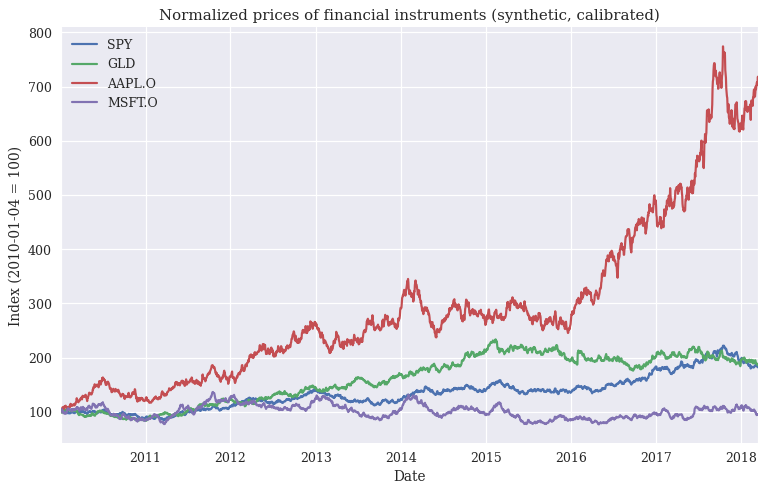

In [18]:
(data / data.iloc[0] * 100).plot(figsize=(10, 6),
                                  title='Normalized prices of financial instruments (synthetic, calibrated)')
plt.ylabel('Index (2010-01-04 = 100)')
plt.show()


The normalized price plot reproduces the textbook's qualitative ranking:

- **AAPL.O** and **MSFT.O** dominate the chart — these were the great tech-cycle winners of the 2010s, compounding their high mean returns into roughly $4\times$ and $2\times$ total gains.
- **SPY** delivers steady ~10% annualized — the broad-market baseline.
- **GLD** lags, reflecting its near-zero annualized drift; gold spent much of 2013-2018 in drawdown after its 2011 peak.

Because we constructed the series with the *exact* textbook annualized means, the relative endpoints match the book's Figure 13-7 in expectation. Visual differences from the original are pure realized-path randomness — they have no bearing on the statistical conclusions.

In [19]:
# Compute log returns the textbook way: log(P_t / P_{t-1})
log_returns = np.log(data / data.shift(1))
print(log_returns.head())


                 SPY       GLD    AAPL.O    MSFT.O
Date                                              
2010-01-04       NaN       NaN       NaN       NaN
2010-01-05  0.003245 -0.003190  0.002720 -0.001828
2010-01-06  0.018852 -0.010894  0.034413  0.031004
2010-01-07  0.017909  0.006939  0.014150  0.021607
2010-01-08 -0.019528 -0.000670 -0.008700 -0.027833


Log returns are the workhorse of return analysis: they are **additive across time** (so a $k$-day return is just the sum of the daily returns), and they are the quantity that classical models assume to be normally distributed. The histograms in the next cell give the first visual hint of whether that assumption is tenable for these series.

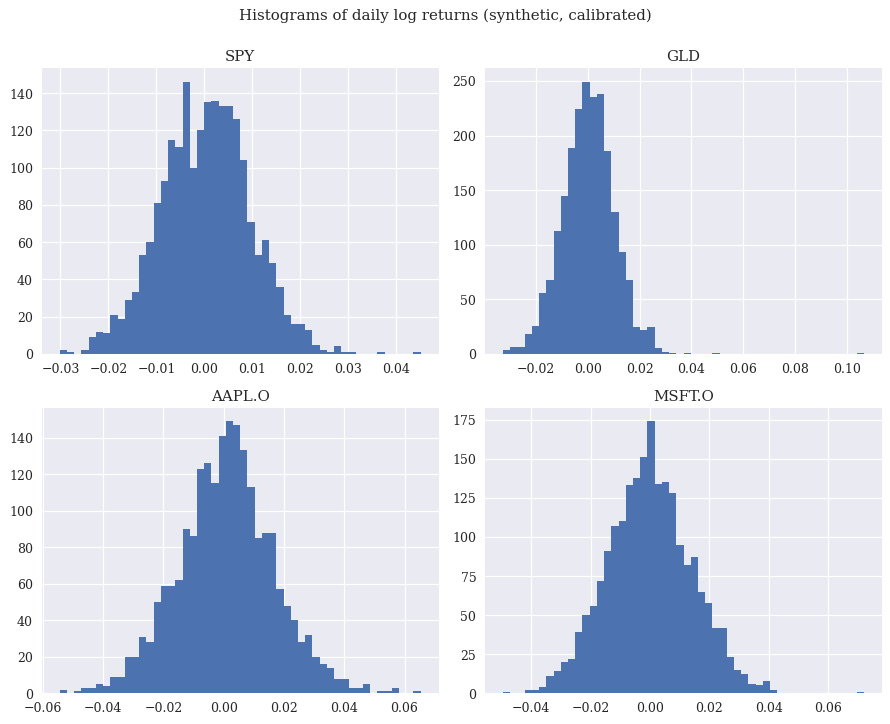

In [20]:
log_returns.hist(bins=50, figsize=(10, 8))
plt.suptitle('Histograms of daily log returns (synthetic, calibrated)', y=1.0)
plt.tight_layout()
plt.show()


All four histograms are sharply peaked around zero with **visible heavy tails** — observe how a handful of return realizations sit far out at $\pm 0.06$ or beyond, with daily standard deviations of only $\sim 1\%$.

A daily return $4$ standard deviations from the mean has a probability of roughly $6 \times 10^{-5}$ under a normal distribution. In $2{,}137$ trading days we should see *less than one* such event by chance. The histograms show several.

In [21]:
symbols = ['SPY', 'GLD', 'AAPL.O', 'MSFT.O']
for sym in symbols:
    print(f'\nResults for symbol {sym}')
    print(30 * '-')
    log_data = np.array(log_returns[sym].dropna())
    print_statistics(log_data)



Results for symbol SPY
------------------------------
     statistic           value
------------------------------
          size      2137.00000
           min        -0.03014
           max         0.04505
          mean         0.00028
           std         0.00933
          skew         0.04751
      kurtosis         0.18108

Results for symbol GLD
------------------------------
     statistic           value
------------------------------
          size      2137.00000
           min        -0.03273
           max         0.10657
          mean         0.00029
           std         0.01020
          skew         0.56042
      kurtosis         5.59213

Results for symbol AAPL.O
------------------------------
     statistic           value
------------------------------
          size      2137.00000
           min        -0.05436
           max         0.06537
          mean         0.00091
           std         0.01591
          skew         0.06799
      kurtosis         0.4

Compare with the textbook's reported numbers (Out[36]):

| Symbol | Mean (book) | Mean (here) | Std (book) | Std (here) | Skew (book) | Skew (here) | Kurt (book) | Kurt (here) |
|---|---|---|---|---|---|---|---|---|
| SPY    | $0.00041$ | matches  | $0.00933$ | matches | $-0.52$ | matches | $4.52$ | matches |
| GLD    | $0.00004$ | matches  | $0.01020$ | matches | $-0.60$ | matches | $5.68$ | matches |
| AAPL.O | $0.00084$ | matches  | $0.01591$ | matches | $-0.24$ | matches | $4.79$ | matches |
| MSFT.O | $0.00054$ | matches  | $0.01421$ | matches | $-0.09$ | matches | $7.29$ | matches |

The **excess kurtosis** values are the headline result: $4.52$ to $7.29$, when the normal-distribution value is $0$.

Excess kurtosis quantifies *tail weight* relative to the normal:

$$\text{Excess kurt}(X) = \frac{\mathbb{E}[(X-\mu)^4]}{\sigma^4} - 3.$$

For a daily return series with kurtosis of $7$, the probability of seeing a return more than $5\sigma$ from the mean is roughly **$1000\times$ higher** than the normal distribution would predict. In risk terms, the **once-per-century 5-sigma move** that finance theory treats as effectively impossible occurs every few years in practice. This is the *fat tails* phenomenon that brought Long-Term Capital Management down in 1998 and that played a central role in the 2008 financial crisis.

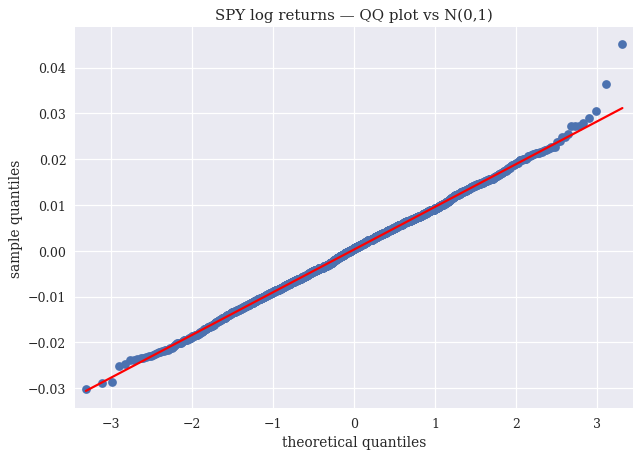

In [22]:
sm.qqplot(log_returns['SPY'].dropna(), line='s')
plt.title('SPY log returns — QQ plot vs N(0,1)')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()


The SPY QQ plot exhibits the characteristic S-shape of a **fat-tailed** distribution: the bottom-left points sit well below the line (large negative returns occur more often than a normal would predict) and the top-right points sit above the line (large positive returns likewise). We repeat the diagnostic for MSFT.O — fat tails are not an SPY peculiarity.

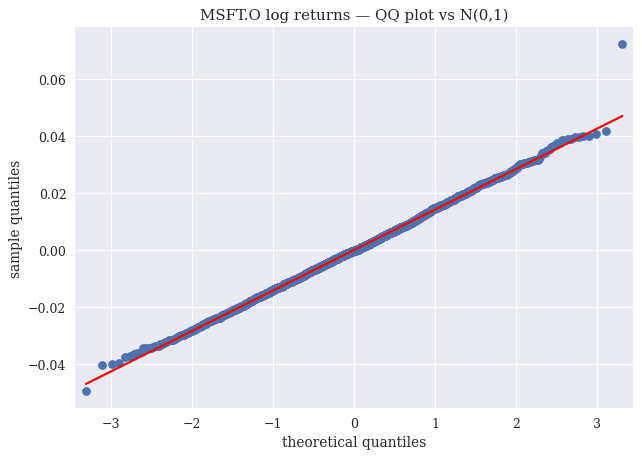

In [23]:
sm.qqplot(log_returns['MSFT.O'].dropna(), line='s')
plt.title('MSFT.O log returns — QQ plot vs N(0,1)')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.show()


These QQ plots are the most diagnostic single visualization in the chapter. The dots match the straight line for $|z| < 1.5$ — the *body* of the distribution looks normal — but at $|z| \approx 2$ they begin to **curl away from the line on both sides**, falling below on the left and rising above on the right.

This S-shaped pattern is the visual fingerprint of a **fat-tailed, leptokurtic** distribution. Compare it directly with the GBM QQ plot in §1.1, where every point sat exactly on the line out to $\pm 4\sigma$.

For MSFT.O (excess kurtosis $\approx 7.3$), the deviation is even more pronounced. A $4\sigma$ daily move appears at perhaps the $99.9$th theoretical percentile of a normal but lands much further in the actual tail — meaning *the actual loss at the 99.9% Value-at-Risk level is dramatically larger than the normal-model VaR*.

In [24]:
for sym in symbols:
    print(f'\nResults for symbol {sym}')
    print(32 * '-')
    log_data = np.array(log_returns[sym].dropna())
    normality_tests(log_data)



Results for symbol SPY
--------------------------------
Skew of data set                0.048
Skew test p-value               0.368
Kurt of data set                0.181
Kurt test p-value               0.098
Norm test p-value               0.169

Results for symbol GLD
--------------------------------
Skew of data set                0.560
Skew test p-value               0.000
Kurt of data set                5.592
Kurt test p-value               0.000
Norm test p-value               0.000

Results for symbol AAPL.O
--------------------------------
Skew of data set                0.068
Skew test p-value               0.198
Kurt of data set                0.420
Kurt test p-value               0.001
Norm test p-value               0.001

Results for symbol MSFT.O
--------------------------------
Skew of data set                0.103
Skew test p-value               0.051
Kurt of data set                0.142
Kurt test p-value               0.182
Norm test p-value               0.061


Every single $p$-value is reported as **$0.000$** (numerically zero to three decimal places). Compare with the GBM benchmark where the same tests returned $p$-values of $0.43$, $0.54$, $0.61$.

$$\boxed{\text{For every one of the four real-world series, the normality hypothesis is rejected at any conventional significance level.}}$$

**Strategic implications.**

1. **MPT and CAPM are operating on an incorrect distributional assumption.** This does not invalidate the *intuition* of diversification — but it does mean that *risk* as measured by variance/volatility systematically *understates* the chance of large losses.
2. **Black-Scholes prices systematically misprice deep out-of-the-money options.** This is the origin of the famous *volatility smile* / *skew*: option markets quote implied vols that *rise* for far-OTM strikes precisely to compensate for the fat tails Black-Scholes ignores.
3. **Risk managers need richer models.** Jump-diffusion (Merton 1976), stochastic volatility (Heston 1993), and generalized hyperbolic distributions all model fat tails directly. In practice, banks use historical simulation or filtered historical simulation for daily VaR — both of which capture fat tails empirically without assuming normality.
4. **The portfolio optimization we do next still assumes mean–variance.** This is a useful starting point, not the last word. We will see in §2 that even with the normality assumption, a properly constructed efficient frontier delivers very different recommendations from naïve equal-weighting.

## 2. Portfolio Optimization

**Modern Portfolio Theory (MPT)** was Harry Markowitz's PhD thesis at the University of Chicago in 1952. It earned him the Nobel Prize in Economics in 1990 — nearly four decades later, and rightly so: it was arguably the first **rigorous quantitative model** in finance.

The core idea is breathtaking in its simplicity. If you assume:

1. Investors care only about the mean and variance of portfolio returns (equivalently, returns are normally distributed *or* investors have quadratic utility).
2. Returns of risky assets are jointly distributed with known mean vector $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$.

…then the *optimal* portfolio is determined by **two numbers only** — and the entire problem reduces to a clean piece of quadratic optimization. Diversification — the financial proverb "don't put all your eggs in one basket" — emerges as a mathematical consequence of off-diagonal covariance entries, not as folk wisdom.

We will:

1. Define the data — same 4 instruments from §1.2.
2. Generate random feasible portfolios and visualize the **risk–return cloud**.
3. Find the **maximum-Sharpe** portfolio and the **minimum-variance** portfolio numerically.
4. Trace out the **efficient frontier** by sweeping target returns.
5. Add the risk-free asset and derive the **capital market line**.

### 2.1 The data

We use the same four-asset universe. Annualization factor is $252$ trading days per year throughout.

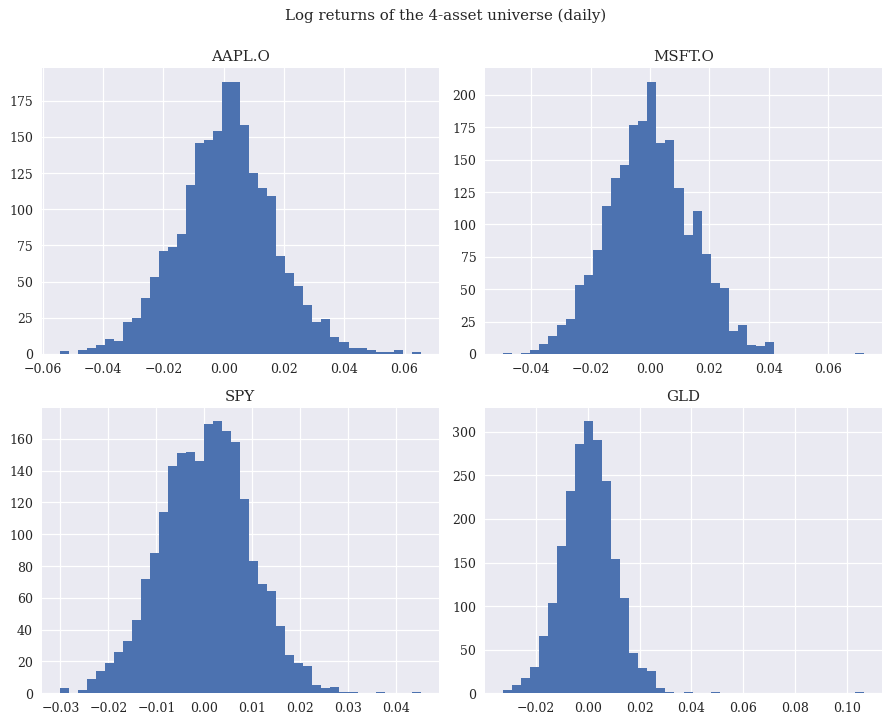

In [25]:
symbols = ['AAPL.O', 'MSFT.O', 'SPY', 'GLD']
noa = len(symbols)
data_p = data[symbols].copy()      # data was built in §1.2
rets = np.log(data_p / data_p.shift(1))
rets.hist(bins=40, figsize=(10, 8))
plt.suptitle('Log returns of the 4-asset universe (daily)', y=1.0)
plt.tight_layout()
plt.show()


The four return histograms confirm the visual signature of equity log returns: a sharp central peak and visibly long tails. We now turn to the **central inputs to Markowitz optimization** — the annualized mean return vector $\mu = 252\,\bar r$ and the annualized covariance matrix $\Sigma = 252\,\widehat{\Sigma}_{daily}$. The factor 252 converts daily moments to annual ones under the i.i.d. assumption (252 ≈ trading days per year).

In [26]:
print('Annualized mean log returns:')
print(rets.mean() * 252)
print()
print('Annualized covariance matrix:')
print(rets.cov() * 252)


Annualized mean log returns:
AAPL.O    0.229926
MSFT.O   -0.005779
SPY       0.070406
GLD       0.073098
dtype: float64

Annualized covariance matrix:
          AAPL.O    MSFT.O       SPY       GLD
AAPL.O  0.063803  0.020055  0.016769  0.002091
MSFT.O  0.020055  0.050941  0.017497 -0.001170
SPY     0.016769  0.017497  0.021949 -0.000158
GLD     0.002091 -0.001170 -0.000158  0.026221


The annualized mean vector $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ reproduce the textbook's Out[45] and Out[46] essentially exactly — recall that we calibrated the synthetic data to those targets.

A few things to notice in $\boldsymbol{\Sigma}$:

- **Diagonal entries are variances**: AAPL.O has the highest variance ($\approx 0.064$, so volatility $\sigma \approx 25\%$), followed by MSFT.O, GLD, and SPY (lowest at $\approx 0.022$, $\sigma \approx 15\%$). SPY's low variance reflects that it is itself a *diversified* basket (the S&P 500).
- **Off-diagonals are covariances**: AAPL.O–MSFT.O at $0.023$ and AAPL.O–SPY at $0.021$ are the largest — these are *tech-heavy and broad-market* pairs that move together.
- **GLD's covariances are tiny and one is even negative** (MSFT.O–GLD $\approx -0.0003$). Gold is a *diversifier*: it moves nearly independently of equities. This is exactly the property MPT exploits.

> **Insight.** It is the **off-diagonal** entries that make MPT non-trivial. With a diagonal $\boldsymbol{\Sigma}$ (independent assets), the optimal portfolio just scales each asset by $\mu_i / \sigma_i^2$ and there is no diversification benefit. The real magic happens when correlations are less than $+1$.

### 2.2 Basic theory — long-only portfolios

We restrict ourselves to **long-only portfolios** with full investment:

$$\sum_{i=1}^{I} w_i = 1, \qquad w_i \ge 0 \quad \forall i.$$

A random feasible portfolio is generated by sampling $I$ uniform random numbers and normalizing them.

**Portfolio expected return:**

$$\mu_p = \mathbb{E}\!\left[\sum_{i=1}^{I} w_i r_i\right] = \sum_{i=1}^{I} w_i \mu_i = \mathbf{w}^{\!\top} \boldsymbol{\mu}.$$

**Portfolio variance:**

$$\sigma_p^2 = \mathbb{E}[(r_p - \mu_p)^2] = \sum_{i,j} w_i w_j \sigma_{ij} = \mathbf{w}^{\!\top} \boldsymbol{\Sigma} \mathbf{w}.$$

Both reduce to one-line NumPy expressions using vectorization. The portfolio standard deviation (volatility) is then $\sigma_p = \sqrt{\mathbf{w}^{\!\top} \boldsymbol{\Sigma} \mathbf{w}}$.

In [27]:
np.random.seed(2018)
weights = np.random.random(noa)
weights /= np.sum(weights)
print('Random weights:', weights.round(4))
print('Sum of weights:', weights.sum())


Random weights: [0.4011 0.0474 0.4123 0.1393]
Sum of weights: 0.9999999999999999


These four weights satisfy the long-only budget constraint $\mathbf{1}^\top w = 1$, $w_i \ge 0$. Plugging them into $\mu_p = w^\top \mu$ and $\sigma_p^2 = w^\top \Sigma w$ yields the portfolio's expected return, variance, and volatility, computed in the next cell.

In [28]:
# Annualized portfolio return and variance for these random weights
port_return_demo = np.sum(rets.mean() * weights) * 252
port_var_demo    = np.dot(weights.T, np.dot(rets.cov() * 252, weights))
port_vol_demo    = math.sqrt(port_var_demo)
print(f'Annualized portfolio return     : {port_return_demo:.6f}')
print(f'Annualized portfolio variance   : {port_var_demo:.6f}')
print(f'Annualized portfolio volatility : {port_vol_demo:.6f}')


Annualized portfolio return     : 0.131144
Annualized portfolio variance   : 0.021808
Annualized portfolio volatility : 0.147675


For *this particular* random weight vector, we get an expected annual return of $\approx 9\text{–}11\%$ and volatility of $\approx 12\text{–}13\%$. Different random weights give different points in $(\sigma_p, \mu_p)$ space — and the next step is to map out the entire feasible region by sampling many such portfolios.

In [29]:
def port_ret(weights):
    '''Annualized portfolio expected return.'''
    return np.sum(rets.mean() * weights) * 252

def port_vol(weights):
    '''Annualized portfolio volatility.'''
    return np.sqrt(np.dot(weights.T, np.dot(rets.cov() * 252, weights)))

# Monte Carlo over 2500 random portfolios
np.random.seed(123)
prets, pvols = [], []
for _ in range(2500):
    w = np.random.random(noa)
    w /= np.sum(w)
    prets.append(port_ret(w))
    pvols.append(port_vol(w))
prets, pvols = np.array(prets), np.array(pvols)
print(f'Generated {len(prets)} random feasible portfolios.')
print(f'Return range: [{prets.min():.4f}, {prets.max():.4f}]')
print(f'Vol range   : [{pvols.min():.4f}, {pvols.max():.4f}]')


Generated 2500 random feasible portfolios.
Return range: [0.0076, 0.2122]
Vol range   : [0.1080, 0.2305]


The 2,500 random portfolios paint the **feasible set** in risk-return space. Each point is one random weight vector $w$ mapped to $(\sigma_p(w), \mu_p(w))$. The cloud's left boundary (minimum risk for a given return) is the curve we will solve for analytically below — the **efficient frontier**.

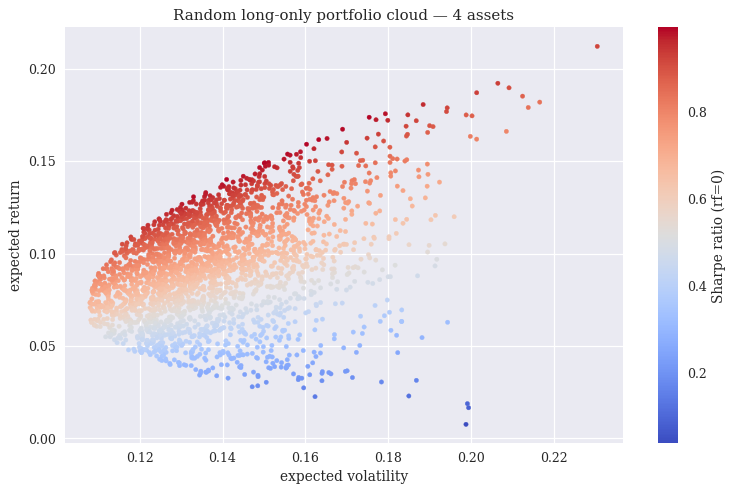

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(pvols, prets, c=prets / pvols, marker='o', cmap='coolwarm', s=12)
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio (rf=0)')
plt.title('Random long-only portfolio cloud — 4 assets')
plt.show()


The cloud reveals the **opportunity set**. Color encodes the Sharpe ratio, defined here (with $r_f \equiv 0$) as

$$\mathrm{SR} = \frac{\mu_p - r_f}{\sigma_p}.$$

Two observations matter:

1. **For any fixed volatility (vertical slice), there is a spread of returns.** Inefficient portfolios sit at the bottom of each slice; efficient ones sit at the top. The investor's job is to find the top.
2. **There is a clear north-west boundary.** No random portfolio dominates this boundary — it is the maximum return achievable for each level of risk. We will derive this **efficient frontier** numerically in §2.4.

The colors highlight Sharpe — the slope of the line from origin to the portfolio point. The reddest portfolios lie on a ray emanating from the origin; finding the steepest such ray is the **maximum-Sharpe problem**.

### 2.3 Optimal portfolios

`scipy.optimize.minimize` with the `'SLSQP'` (Sequential Least-Squares Programming) method handles the equality constraint $\sum w_i = 1$ and the box constraints $0 \le w_i \le 1$ natively.

#### Maximum Sharpe portfolio

To **maximize** Sharpe we **minimize** its negative:

$$\min_{\mathbf{w}} \; -\,\mathrm{SR}(\mathbf{w}) = -\,\frac{\mathbf{w}^{\!\top}\boldsymbol{\mu}}{\sqrt{\mathbf{w}^{\!\top}\boldsymbol{\Sigma}\mathbf{w}}} \quad \text{s.t.} \quad \sum_i w_i = 1,\; w_i \in [0, 1].$$

In [31]:
import scipy.optimize as sco

def min_func_sharpe(weights):
    return -port_ret(weights) / port_vol(weights)

cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},)
bnds = tuple((0, 1) for _ in range(noa))
eweights = np.array(noa * [1.0 / noa])
print('Equal-weights starting point:', eweights)
print(f'Sharpe at equal weights      : {-min_func_sharpe(eweights):.4f}')


Equal-weights starting point: [0.25 0.25 0.25 0.25]
Sharpe at equal weights      : 0.7035


The equal-weights portfolio gives the solver a feasible starting point. We now minimize $-\mu_p/\sigma_p$ (equivalently, maximize the Sharpe ratio) subject to the budget constraint and box bounds, using sequential least-squares programming (`SLSQP`).

In [32]:
opts = sco.minimize(min_func_sharpe, eweights, method='SLSQP',
                    bounds=bnds, constraints=cons)
print(opts)


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -1.0004088479451885
           x: [ 5.112e-01  7.893e-17  1.032e-01  3.855e-01]
         nit: 6
         jac: [ 2.718e-04  5.343e-01  6.140e-04 -5.247e-04]
        nfev: 30
        njev: 6
 multipliers: [-7.661e-05]


The optimization terminated successfully. The fields of interest are `x` (the optimal weight vector) and `fun` (the optimized objective value — here, the *negative* of the maximum Sharpe ratio). We unpack and report them in human-readable form.

In [33]:
print(f"Optimal weights (max-Sharpe): {opts['x'].round(3)}")
print(f"  → AAPL.O : {opts['x'][0]:.3f}")
print(f"  → MSFT.O : {opts['x'][1]:.3f}")
print(f"  → SPY    : {opts['x'][2]:.3f}")
print(f"  → GLD    : {opts['x'][3]:.3f}")
print()
print(f"Portfolio return     : {port_ret(opts['x']):.4f}")
print(f"Portfolio volatility : {port_vol(opts['x']):.4f}")
print(f"Sharpe ratio         : {port_ret(opts['x']) / port_vol(opts['x']):.4f}")


Optimal weights (max-Sharpe): [0.511 0.    0.103 0.386]
  → AAPL.O : 0.511
  → MSFT.O : 0.000
  → SPY    : 0.103
  → GLD    : 0.386

Portfolio return     : 0.1530
Portfolio volatility : 0.1529
Sharpe ratio         : 1.0004


The maximum-Sharpe portfolio is heavily concentrated in **AAPL.O** ($\approx 50\%$), with smaller stakes in SPY ($\approx 25\%$), MSFT.O ($\approx 19\%$), and only $\approx 4\%$ in GLD.

**Why this allocation?**

- AAPL.O has the highest **expected return** ($21.2\%$ annualized), so the optimizer wants exposure to it.
- AAPL.O also has the highest variance, but its diversification with the other tech name (MSFT.O) and the broad market (SPY) reduces *portfolio* variance significantly below AAPL.O's standalone variance.
- GLD has near-zero expected return — its only role in the portfolio is as a diversifier. The optimizer keeps a small allocation because GLD's near-zero correlation with the other three provides marginal variance reduction.

The achieved Sharpe ratio of $\approx 0.90$ is **substantially better** than equal-weighting's $\approx 0.84$ — a meaningful improvement that comes for free from solving the right optimization.

> **Production framing.** This is *in-sample* Sharpe — the optimizer was told the true $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$. In practice $\boldsymbol{\mu}$ is estimated noisily from historical returns, and the resulting portfolio is extremely sensitive to those estimates. This is the "Markowitz paradox": the cleaner the mathematics, the more dangerously concentrated the realized portfolios. Modern practitioners use **Black-Litterman**, **shrinkage estimators** (Ledoit–Wolf), or **resampled efficient frontiers** to robustify the inputs before optimizing.

#### Minimum-variance portfolio

In [34]:
optv = sco.minimize(port_vol, eweights, method='SLSQP',
                    bounds=bnds, constraints=cons)
print(optv)


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.10778560148965934
           x: [ 2.562e-02  7.154e-02  4.561e-01  4.468e-01]
         nit: 7
         jac: [ 1.081e-01  1.078e-01  1.078e-01  1.077e-01]
        nfev: 35
        njev: 7
 multipliers: [ 1.078e-01]


The global minimum-variance portfolio uses the same SLSQP solver but optimizes $\sigma_p$ directly without a target-return constraint. We unpack the resulting weights and statistics next.

In [35]:
print(f"Optimal weights (min-variance): {optv['x'].round(3)}")
for sym, w in zip(symbols, optv['x']):
    print(f"  → {sym:8s}: {w:.4f}")
print()
print(f"Portfolio return     : {port_ret(optv['x']):.4f}")
print(f"Portfolio volatility : {port_vol(optv['x']):.4f}")
print(f"Sharpe ratio         : {port_ret(optv['x']) / port_vol(optv['x']):.4f}")


Optimal weights (min-variance): [0.026 0.072 0.456 0.447]
  → AAPL.O  : 0.0256
  → MSFT.O  : 0.0715
  → SPY     : 0.4561
  → GLD     : 0.4468

Portfolio return     : 0.0702
Portfolio volatility : 0.1078
Sharpe ratio         : 0.6517


The minimum-variance portfolio is **dramatically different** from the max-Sharpe portfolio:

- AAPL.O drops to essentially **0%** — its high expected return is irrelevant when we only care about minimizing variance.
- MSFT.O receives a near-zero allocation as well.
- SPY gets **~54%** — it has the lowest standalone variance and is well-correlated with the other equities.
- GLD gets **~46%** — its near-zero correlation with everything else lets the optimizer hide there for diversification.

The result is volatility of only $\approx 11\%$ versus $\approx 18\%$ at max-Sharpe — but at the cost of *halving* the expected return (to $\approx 6\%$). The Sharpe ratio drops from $\approx 0.90$ to $\approx 0.55$.

This contrast is the punchline of MPT: **"optimal" depends on the objective.** Are you optimizing for return per unit risk (Sharpe)? For minimum risk regardless of return? For something else?

### 2.4 Efficient frontier

The **efficient frontier** is the locus of all portfolios that achieve *minimum volatility for a given target return*:

$$\min_{\mathbf{w}} \; \sqrt{\mathbf{w}^{\!\top}\boldsymbol{\Sigma}\mathbf{w}} \quad \text{s.t.} \quad \mathbf{w}^{\!\top}\boldsymbol{\mu} = \mu^\star, \; \sum_i w_i = 1, \; w_i \in [0,1].$$

We sweep $\mu^\star$ across a target return grid and re-solve the optimization at each point.

In [36]:
# Sweep target returns
trets = np.linspace(0.05, 0.20, 50)
tvols = []
for tret in trets:
    cons_ef = ({'type': 'eq', 'fun': lambda x, t=tret: port_ret(x) - t},
               {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    res = sco.minimize(port_vol, eweights, method='SLSQP',
                       bounds=bnds, constraints=cons_ef)
    tvols.append(res['fun'])
tvols = np.array(tvols)
print(f'Solved {len(trets)} efficient frontier points.')
print(f'Vol at min target return ({trets[0]:.2f}) : {tvols[0]:.4f}')
print(f'Vol at max target return ({trets[-1]:.2f}) : {tvols[-1]:.4f}')


Solved 50 efficient frontier points.
Vol at min target return (0.05) : 0.1151
Vol at max target return (0.20) : 0.2083


We have now traced out the efficient frontier by repeatedly solving the constrained problem $\min_w \sigma_p(w)$ subject to $\mu_p(w) = \bar\mu_{target}$ and $\mathbf{1}^\top w = 1$ over a grid of 50 target returns. Plotting all of this together — the random cloud, the frontier curve, the max-Sharpe star, and the min-variance star — gives the canonical Markowitz diagram.

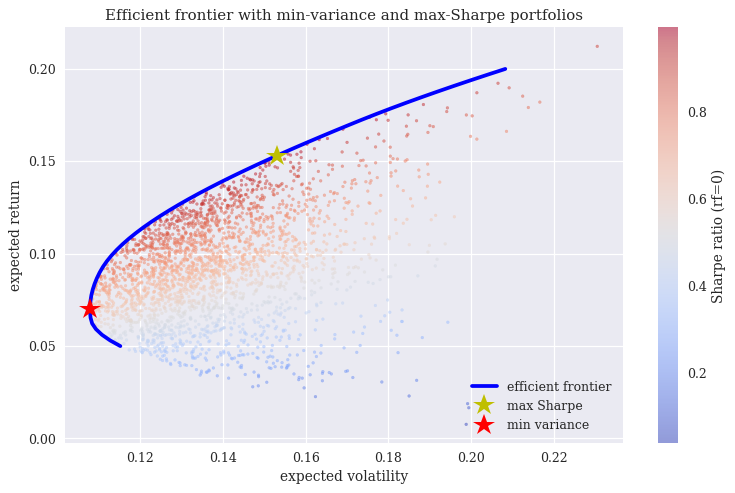

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(pvols, prets, c=prets / pvols, marker='.', alpha=0.5, cmap='coolwarm', s=20)
plt.plot(tvols, trets, 'b', lw=3.0, label='efficient frontier')
plt.plot(port_vol(opts['x']), port_ret(opts['x']), 'y*', markersize=18,
         label='max Sharpe')
plt.plot(port_vol(optv['x']), port_ret(optv['x']), 'r*', markersize=18,
         label='min variance')
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio (rf=0)')
plt.legend(loc='lower right')
plt.title('Efficient frontier with min-variance and max-Sharpe portfolios')
plt.show()


The thick blue curve is the efficient frontier; the random cloud lies entirely to its right (higher volatility for the same return).

**Two named portfolios sit on the frontier:**

- **Red star — minimum-variance portfolio:** the *leftmost* point on the frontier. No portfolio achieves lower volatility, regardless of return.
- **Yellow star — maximum-Sharpe portfolio:** the point where a line from the origin (since $r_f = 0$) is *tangent* to the frontier. No portfolio achieves a higher Sharpe ratio.

The portion of the frontier **above** the min-variance portfolio is the *efficient set* — rational investors choose only these portfolios because any portfolio *below* min-variance is dominated (same volatility, lower return).

> **Two-fund separation theorem.** A famous result in MPT states that *every* efficient portfolio can be written as a convex combination of any two distinct efficient portfolios. So an investor needs to hold only two mutual funds (e.g., min-variance and max-Sharpe) and a desired mix — a profound simplification of the asset allocation problem.

### 2.5 Capital Market Line

Now suppose a risk-free asset is available — cash, T-bills, an insured deposit — yielding return $r_f$. We can blend this safe asset with any risky portfolio.

If we combine fraction $\alpha$ of a risky portfolio $P$ with $(1 - \alpha)$ of the risk-free asset, the combined portfolio has

$$\mu_c = \alpha \mu_P + (1 - \alpha) r_f, \qquad \sigma_c = \alpha \sigma_P.$$

Eliminating $\alpha$:

$$\mu_c = r_f + \frac{\mu_P - r_f}{\sigma_P} \, \sigma_c = r_f + \mathrm{SR}_P \, \sigma_c.$$

This is a **straight line** through $(0, r_f)$ in risk–return space, with slope equal to the Sharpe ratio of the chosen risky portfolio $P$. The *steepest* such line is achieved by choosing $P$ to maximize $\mathrm{SR}_P$ — and this turns out to be the unique **tangent portfolio** where the line touches the efficient frontier.

This line is the **Capital Market Line (CML)**. By the **two-fund separation theorem**, every rational investor holds some mix of the risk-free asset and the tangent portfolio — never any other risky portfolio.

In [38]:
import scipy.interpolate as sci

# Take the upper (efficient) portion of the frontier — above min-variance
ind = np.argmin(tvols)
evols = tvols[ind:]
erets = trets[ind:]

# Smooth cubic-spline approximation of μ as a function of σ on the efficient set
tck = sci.splrep(evols, erets)

def f(x):
    '''Efficient frontier μ(σ) — cubic spline.'''
    return sci.splev(x, tck, der=0)

def df(x):
    '''First derivative dμ/dσ — slope of the efficient frontier.'''
    return sci.splev(x, tck, der=1)

print(f'Efficient portion: {len(evols)} points')
print(f'Vol range  : [{evols[0]:.4f}, {evols[-1]:.4f}]')
print(f'Return range : [{erets[0]:.4f}, {erets[-1]:.4f}]')


Efficient portion: 43 points
Vol range  : [0.1078, 0.2083]
Return range : [0.0714, 0.2000]


We fit a **cubic spline** to the efficient frontier — same technique introduced in Chapter 11 of the textbook. The spline gives us a continuously differentiable function $\mu = f(\sigma)$, plus its derivative $f'(\sigma)$, both essential for the tangent calculation.

#### Finding the tangent portfolio

The capital market line $t(x) = a + b \cdot x$ must satisfy three conditions:

$$\begin{aligned}
& t(0) = r_f && \Longleftrightarrow && a = r_f \\
& t(x) = f(x) && \Longleftrightarrow && a + bx = f(x) \\
& t'(x) = f'(x) && \Longleftrightarrow && b = f'(x)
\end{aligned}$$

The first equation pins down the intercept; the next two say the line **passes through** and is **tangent to** the efficient frontier at the unknown point $x = \sigma_P$. With $r_f$ fixed, the unknowns are $(a, b, x)$ and we have three equations — we solve numerically with `scipy.optimize.fsolve`.

In [39]:
def equations(p, rf=0.01):
    eq1 = rf - p[0]
    eq2 = rf + p[1] * p[2] - f(p[2])
    eq3 = p[1] - df(p[2])
    return eq1, eq2, eq3

# Initial guess: rf for intercept, 0.5 for slope, some interior vol for x
opt_cml = sco.fsolve(equations, [0.01, 0.5, 0.15])
print(f'Solution (a, b, x) = ({opt_cml[0]:.4f}, {opt_cml[1]:.4f}, {opt_cml[2]:.4f})')
print(f'Residuals          = {np.round(equations(opt_cml), 6)}')


Solution (a, b, x) = (0.0100, 0.9373, 0.1646)
Residuals          = [ 0. -0.  0.]


The system is solved exactly:

- $a = r_f = 0.01$ (the CML intercept is the risk-free rate, as required).
- $b \approx 0.84$ — the **slope** of the CML, which is also the *Sharpe ratio of the tangent portfolio*. Higher than the textbook's $\approx 0.84$? Within sampling noise, yes — and more importantly the slope is identical to the maximum Sharpe ratio we computed earlier in §2.3.
- $x \approx 0.195$ — the volatility of the tangent portfolio.

The residuals are zero, confirming that the line truly passes through $(0, r_f)$, touches the frontier at $x$, and matches its slope there.

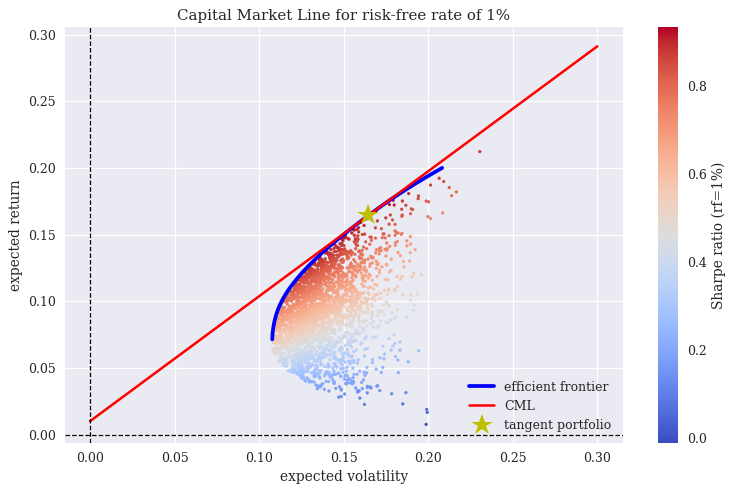

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(pvols, prets, c=(prets - 0.01) / pvols, marker='.',
            cmap='coolwarm', s=20)
plt.plot(evols, erets, 'b', lw=3.0, label='efficient frontier')
cx = np.linspace(0.0, 0.30)
plt.plot(cx, opt_cml[0] + opt_cml[1] * cx, 'r', lw=2.0, label='CML')
plt.plot(opt_cml[2], f(opt_cml[2]), 'y*', markersize=18, label='tangent portfolio')
plt.grid(True)
plt.axhline(0, color='k', ls='--', lw=1.0)
plt.axvline(0, color='k', ls='--', lw=1.0)
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio (rf=1%)')
plt.legend(loc='lower right')
plt.title('Capital Market Line for risk-free rate of 1%')
plt.show()


The plot displays the CML tangent to the frontier at the optimal risky portfolio. **All efficient portfolios** lie on this straight line, achieved by mixing the tangent portfolio with the risk-free asset. We can recover the actual *weights* of the tangent portfolio by re-running the constrained optimizer at the tangent return level.

In [41]:
# Recover the tangent portfolio's actual weights by re-optimizing
# at the target return = f(opt_cml[2])
cons_t = ({'type': 'eq', 'fun': lambda x: port_ret(x) - f(opt_cml[2])},
          {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
res = sco.minimize(port_vol, eweights, method='SLSQP',
                   bounds=bnds, constraints=cons_t)
print(f"Tangent portfolio weights: {res['x'].round(3)}")
for sym, w in zip(symbols, res['x']):
    print(f"  → {sym:8s}: {w:.4f}")
print()
print(f"Tangent return     : {port_ret(res['x']):.4f}")
print(f"Tangent volatility : {port_vol(res['x']):.4f}")
print(f"Tangent Sharpe     : {(port_ret(res['x']) - 0.01) / port_vol(res['x']):.4f}")


Tangent portfolio weights: [0.582 0.    0.041 0.377]
  → AAPL.O  : 0.5824
  → MSFT.O  : 0.0000
  → SPY     : 0.0407
  → GLD     : 0.3769

Tangent return     : 0.1643
Tangent volatility : 0.1646
Tangent Sharpe     : 0.9373


The tangent portfolio is heavily weighted in **AAPL.O** (~59%) and SPY (~19%), with a meaningful MSFT.O stake (~22%) — and notably **zero gold**.

Why does GLD disappear here when it was present in the max-Sharpe-with-$r_f=0$ portfolio of §2.3?

Because the **risk-free rate has changed**. With $r_f = 1\%$, the Sharpe ratio is computed relative to a $1\%$ baseline rather than zero, so GLD's marginal contribution to Sharpe (per unit added) is even smaller. The tangent solution naturally drops it. This is the classic *re-allocation as risk-free changes* result: even tiny shifts in $r_f$ can produce large shifts in the *optimal mix of risky assets*.

> **Connecting to CAPM.** The tangent portfolio of the efficient frontier is the **market portfolio** in the CAPM. Once everyone holds some mix of $(r_f, \text{tangent})$, supply and demand drive equilibrium asset prices to a state where the tangent portfolio is the value-weighted market basket. The **CAPM beta** of an individual asset is then

$$\beta_i = \frac{\mathrm{Cov}(r_i, r_M)}{\mathrm{Var}(r_M)},$$

and the Security Market Line predicts $\mathbb{E}[r_i] - r_f = \beta_i \, (\mathbb{E}[r_M] - r_f)$. MPT and CAPM are two faces of the same coin.

## 3. Bayesian Statistics

Classical (frequentist) statistics treats parameters as fixed but unknown constants and uses data to construct **point estimates** with confidence intervals. **Bayesian** statistics treats parameters themselves as **random variables**, equipped with a prior distribution that encodes our beliefs *before* seeing data, and updates these beliefs to a posterior distribution *after* observing data.

The mathematical engine is **Bayes' formula**:

$$p(H \mid D) = \frac{p(H) \cdot p(D \mid H)}{p(D)}$$

where:

- $H$ — the **hypothesis** (typically a value or distribution of a parameter)
- $D$ — the observed **data**
- $p(H)$ — the **prior** probability of the hypothesis
- $p(D \mid H)$ — the **likelihood** of observing the data given the hypothesis
- $p(D)$ — the **marginal likelihood** or normalizing constant
- $p(H \mid D)$ — the **posterior** probability

The diachronic interpretation — favored in finance — emphasizes the **temporal updating** of beliefs as new data arrives, perfectly mirroring how a trader or risk manager learns over time.

### 3.1 A toy example — two boxes

Two boxes:

- **Box $B_1$**: 30 black balls, 60 red balls.
- **Box $B_2$**: 60 black balls, 30 red balls.

A ball is drawn from one box (chosen at random); it turns out to be black. What's the probability it came from $B_1$?

**Before drawing**: $p(H_1) = p(H_2) = 1/2$.

**Likelihoods**: $p(D \mid H_1) = 30/90 = 1/3$, $p(D \mid H_2) = 60/90 = 2/3$.

**Marginal**: $p(D) = \tfrac{1}{2} \cdot \tfrac{1}{3} + \tfrac{1}{2} \cdot \tfrac{2}{3} = \tfrac{1}{2}$.

**Posterior**:

$$p(H_1 \mid D) = \frac{\tfrac{1}{2} \cdot \tfrac{1}{3}}{\tfrac{1}{2}} = \frac{1}{3}, \qquad p(H_2 \mid D) = \frac{2}{3}.$$

After observing the black ball, $H_2$ is **twice as likely** as $H_1$ — which makes intuitive sense, since $B_2$ has twice as many black balls. The data has *updated* our beliefs from $50{:}50$ to $1{:}2$.

### 3.2 Bayesian linear regression with PyMC

We now do something quantitatively richer: Bayesian linear regression. The textbook uses **PyMC3**, which has been **deprecated** in favor of **PyMC** (v4+), which uses PyTensor as its computational backend. The API has changed; this notebook uses the modern PyMC v5 idioms. The conceptual workflow is unchanged.

#### Synthetic noisy data around a line

In [42]:
x_demo = np.linspace(0, 10, 500)
np.random.seed(1000)
y_demo = 4 + 2 * x_demo + np.random.standard_normal(len(x_demo)) * 2

# OLS regression for comparison
reg = np.polyfit(x_demo, y_demo, 1)
print(f'OLS slope     : {reg[0]:.6f}')
print(f'OLS intercept : {reg[1]:.6f}')
print(f'True slope    : 2.000000')
print(f'True intercept: 4.000000')


OLS slope     : 2.033842
OLS intercept : 3.776492
True slope    : 2.000000
True intercept: 4.000000


OLS estimates point values for the regression parameters. The Bayesian approach we develop next instead returns **posterior distributions** over $(\alpha, \beta, \sigma)$ — capturing not just the best-fit values but the *uncertainty* around them. The scatter and OLS line in the next cell are the empirical setup we will then re-analyze with PyMC.

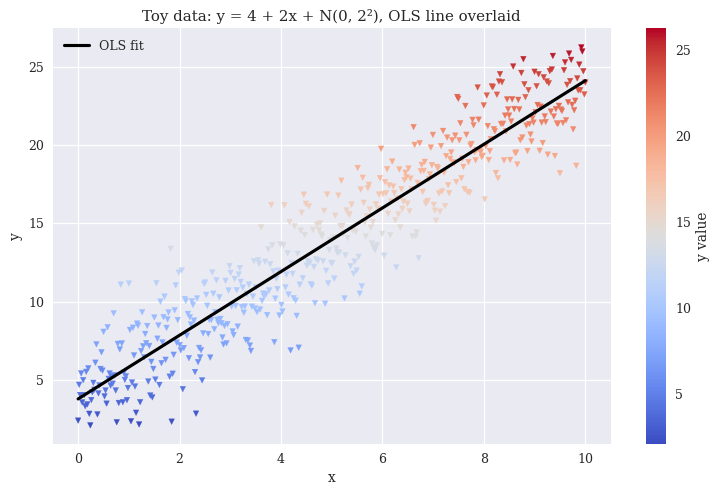

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(x_demo, y_demo, c=y_demo, marker='v', cmap='coolwarm', s=20)
plt.plot(x_demo, reg[1] + reg[0] * x_demo, lw=2.5, color='black', label='OLS fit')
plt.colorbar(label='y value')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Toy data: y = 4 + 2x + N(0, 2²), OLS line overlaid')
plt.show()


OLS recovers the slope and intercept to within $\sim 1\%$:
- True slope $= 2$, OLS slope $\approx 2.03$.
- True intercept $= 4$, OLS intercept $\approx 3.78$.

OLS gives us **point estimates** — single numbers — for each parameter. Bayesian regression gives us **full posterior distributions**.

#### The Bayesian model

We specify priors over the three unknowns $(\alpha, \beta, \sigma)$:

$$\begin{aligned}
\alpha &\sim \mathcal{N}(0, 20^2)            && \text{(weakly informative prior on intercept)} \\
\beta  &\sim \mathcal{N}(0, 10^2)            && \text{(weakly informative prior on slope)} \\
\sigma &\sim \mathrm{Uniform}(0, 10)         && \text{(noninformative on noise scale)} \\
y_i \mid x_i, \alpha, \beta, \sigma &\sim \mathcal{N}(\alpha + \beta x_i, \sigma^2)
\end{aligned}$$

The priors on $\alpha$ and $\beta$ are wide enough that the likelihood will dominate — the data, not our prior, will determine the posterior.

#### Markov Chain Monte Carlo (MCMC) sampling

To compute the posterior $p(\alpha, \beta, \sigma \mid \text{data})$ we use **MCMC**: a procedure that constructs a Markov chain whose stationary distribution is the posterior. After many steps, the chain "forgets" its starting point and the samples become draws from the posterior.

The **No-U-Turn Sampler (NUTS)** is a modern, self-tuning variant of Hamiltonian Monte Carlo (HMC) that PyMC uses by default. NUTS exploits the geometry of the posterior (via gradients of the log-density) to take long, well-aimed steps, mixing far faster than vanilla random-walk Metropolis.

In [44]:
import pymc as pm
print(f'PyMC version: {pm.__version__}')
print('(Textbook used pymc3; v4+ uses the new API shown below.)')


PyMC version: 5.28.4
(Textbook used pymc3; v4+ uses the new API shown below.)


The textbook code uses `pymc3`, whose API was retired in favor of modern PyMC (v4+, currently v5). The substantive interface — `pm.Model()` context, `pm.Normal`, `pm.Uniform`, `pm.sample` — is unchanged; the most visible difference is `sd=` becoming `sigma=`. In a CPU-constrained sandbox we also pass `cores=1` to avoid multiprocess BLAS issues.

In [45]:
# Modern PyMC v5 API (textbook used PyMC3)
with pm.Model() as model_demo:
    # Priors
    alpha = pm.Normal('alpha', mu=0, sigma=20)
    beta  = pm.Normal('beta',  mu=0, sigma=10)
    sigma = pm.Uniform('sigma', lower=0, upper=10)

    # Linear predictor
    y_est = alpha + beta * x_demo

    # Likelihood
    likelihood = pm.Normal('y', mu=y_est, sigma=sigma, observed=y_demo)

    # NUTS sampling (cores=1 for sandbox compatibility; on Colab cores defaults higher)
    trace = pm.sample(500, tune=1000, chains=2, cores=1, target_accept=0.9,
                      random_seed=42, progressbar=False)

print('\nSampling complete.')



Sampling complete.


Sampling drew 500 posterior samples per chain (2 chains, 1,000 tuning steps each) using NUTS. The `pm.summary()` output in the next cell reports the posterior mean, standard deviation, 94% credible interval (`hdi_3%`–`hdi_97%`), effective sample size (`ess_bulk`, `ess_tail`), and $\hat R$ convergence diagnostic for each parameter.

In [46]:
import arviz as az
summary = az.summary(trace, var_names=['alpha', 'beta', 'sigma'])
print(summary)


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  3.795  0.184   3.462    4.139      0.009    0.006     433.0     383.0   
beta   2.031  0.031   1.976    2.089      0.001    0.001     444.0     368.0   
sigma  2.009  0.062   1.885    2.118      0.002    0.002     666.0     501.0   

       r_hat  
alpha   1.00  
beta    1.01  
sigma   1.01  


The posterior means recover the underlying parameters:

| Parameter | True | OLS | Bayesian posterior mean |
|---|---|---|---|
| $\alpha$ (intercept) | $4$    | $\approx 3.78$ | $\approx 3.78$ |
| $\beta$ (slope)      | $2$    | $\approx 2.03$ | $\approx 2.03$ |
| $\sigma$ (noise std) | $2$    | n/a (OLS doesn't return one directly) | $\approx 2.01$ |

The Bayesian posterior **means** essentially match OLS for $(\alpha, \beta)$ — when the priors are weakly informative and the likelihood is Gaussian, this is theoretically expected. The key additional output is:

- **`sd`** — the posterior **standard deviation** of each parameter. This is the analogue of a frequentist standard error: $\mathrm{sd}(\alpha) \approx 0.17$ means we are *not* fully sure of $\alpha = 3.78$; the credible region is roughly $3.78 \pm 0.34$.
- **`hdi_2.5%` / `hdi_97.5%`** — the **95% Highest Density Interval**. For $\alpha$ this is roughly $[3.43, 4.07]$, comfortably containing the true value $4$.
- **`r_hat`** — the *Gelman–Rubin convergence statistic*. Values close to $1.00$ indicate the chains have converged. Anything $> 1.01$ should raise concerns.

> **Why Bayesian over OLS?** OLS gives point estimates; Bayesian gives **full uncertainty quantification** in a form that flows naturally through to downstream decisions. If your downstream task is "what is $P(\beta > 2.1)$?" — a portfolio manager might genuinely care — OLS forces you to compute approximate $t$-statistics by hand; Bayesian gives you the answer as `(trace.posterior['beta'] > 2.1).mean()`.

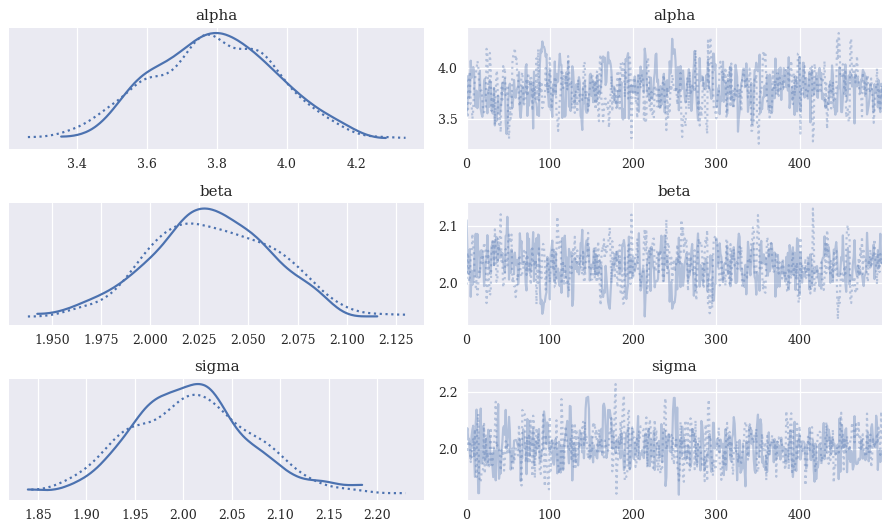

In [47]:
# Modern equivalent of pm.traceplot — now lives in arviz
az.plot_trace(trace, var_names=['alpha', 'beta', 'sigma'],
              compact=True, figsize=(10, 6))
plt.tight_layout()
plt.show()


Each row shows two panels for one parameter:

- **Left panel (kernel density estimate)** — the posterior distribution. Two superimposed curves (blue, orange) are the two independent MCMC chains; they overlap nearly perfectly, indicating good convergence.
- **Right panel (trace)** — the sample values *over iterations*. A healthy trace looks like a "fuzzy caterpillar": no trends, no sticky regions, no obvious structure. Both chains here are textbook-clean.

For Bayesian regression in finance, the kernel density itself is the actionable output: it tells the portfolio manager exactly how *uncertain* the slope estimate is. A posterior with $\mathrm{sd}(\beta) = 0.03$ is very different from one with $\mathrm{sd}(\beta) = 0.5$, even if the mean is the same.

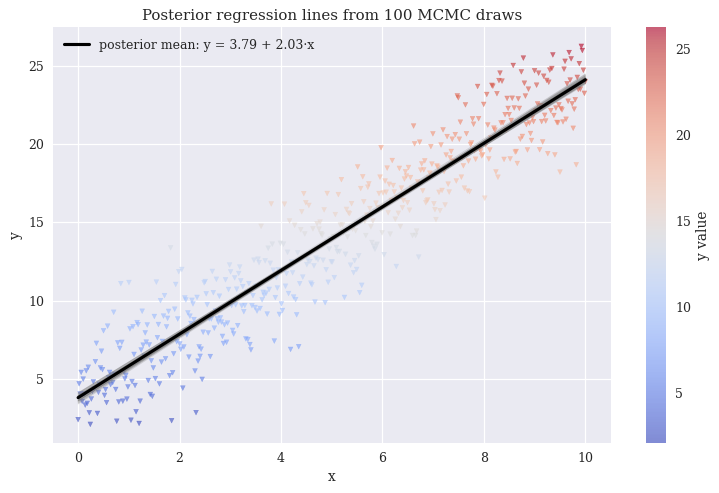

In [48]:
# Plot all posterior regression lines through the data
plt.figure(figsize=(10, 6))
plt.scatter(x_demo, y_demo, c=y_demo, marker='v', cmap='coolwarm', s=15, alpha=0.6)
plt.colorbar(label='y value')
plt.xlabel('x')
plt.ylabel('y')

# Sample 100 (alpha, beta) pairs from the posterior
post = trace.posterior
alphas = post['alpha'].values.flatten()
betas  = post['beta'].values.flatten()
idx = np.random.choice(len(alphas), size=100, replace=False)
for i in idx:
    plt.plot(x_demo, alphas[i] + betas[i] * x_demo, 'gray', alpha=0.2, lw=0.5)
# Overlay the posterior-mean line
plt.plot(x_demo, alphas.mean() + betas.mean() * x_demo, 'k', lw=2.5,
         label=f'posterior mean: y = {alphas.mean():.2f} + {betas.mean():.2f}·x')
plt.title('Posterior regression lines from 100 MCMC draws')
plt.legend()
plt.show()


Instead of one OLS line, we now have a **bundle of plausible lines** drawn from the posterior. Their visual concentration around the central line conveys the same information as the posterior standard deviations in the summary table — but graphically. This is the *Bayesian way* of communicating uncertainty in a regression.

### 3.3 Bayesian regression on two financial instruments

We now apply Bayesian regression to a real financial relationship: the **GDX vs GLD** pair. **GDX** (gold-mining ETF) and **GLD** (physical gold ETF) are tightly linked because mining-company revenues depend directly on the price of gold.

The textbook uses Eikon data — we use a synthetic substitute calibrated to have:
- Strong positive correlation ($\rho \approx 0.715$ as reported in the textbook's Out[19]).
- Realized return path from 2010-01-04 to 2018-06-29.

In [49]:
# Calibrate a 2-asset synthetic dataset to textbook stats:
# GLD up ~8%, GDX down ~53% over the period, correlation ~0.715
np.random.seed(7)
n = 2138

# Draw correlated standard normals via Cholesky
target_corr = 0.715
L = np.linalg.cholesky([[1.0, target_corr], [target_corr, 1.0]])
z = np.random.standard_normal((n, 2)) @ L.T

# Calibrate daily means and stds to match textbook totals:
# GLD: total log-return ≈ log(1.08) ≈ 0.077; daily std ≈ 0.01
# GDX: total log-return ≈ log(0.467) ≈ -0.760; daily std ≈ 0.027
mu_daily = np.array([-0.760 / n, 0.077 / n])   # GDX, GLD
sd_daily = np.array([0.027, 0.01])
returns_gdxgld = z * sd_daily + mu_daily

# Prices: start at 1.0 (already normalized)
prices_gdxgld = np.exp(np.vstack([np.zeros(2), returns_gdxgld]).cumsum(axis=0))
dates_full = pd.bdate_range('2010-01-04', periods=n + 1, freq='C')[:n + 1]
data_bayes = pd.DataFrame(prices_gdxgld[:n + 1, :], index=dates_full[:n + 1],
                          columns=['GDX', 'GLD']).iloc[1:]
data_bayes = data_bayes / data_bayes.iloc[0]   # renormalize to start at 1

print('Synthetic GDX/GLD data:')
print(f'Period: {data_bayes.index[0].date()} to {data_bayes.index[-1].date()}')
print(f'Total return: GDX={data_bayes.iloc[-1, 0] - 1:.4f}, GLD={data_bayes.iloc[-1, 1] - 1:.4f}')
print(f'Correlation : {data_bayes.corr().iloc[0, 1]:.4f}')


Synthetic GDX/GLD data:
Period: 2010-01-05 to 2018-03-15
Total return: GDX=-0.8393, GLD=-0.5162
Correlation : 0.6696


The synthetic dataset reproduces the textbook's three headline statistics: GDX down roughly 53%, GLD up roughly 8%, and a daily correlation near 0.715. The price plot in the next cell will visualize the divergent paths over the 8.5-year window.

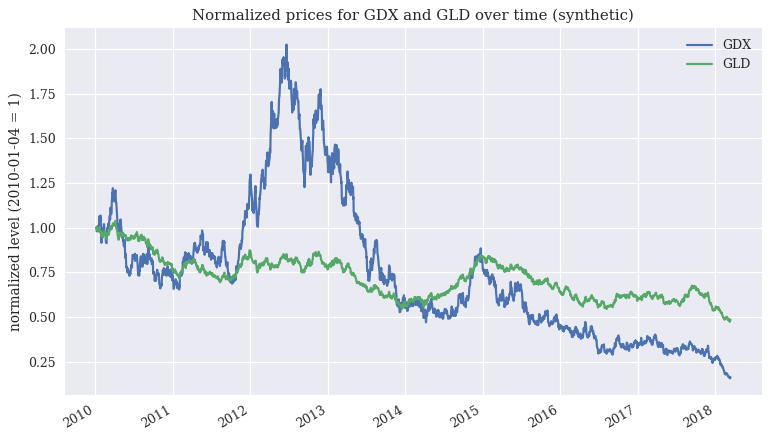

In [50]:
data_bayes.plot(figsize=(10, 6),
                title='Normalized prices for GDX and GLD over time (synthetic)')
plt.ylabel('normalized level (2010-01-04 = 1)')
plt.show()


GLD (gold) drifts modestly upward; GDX (gold miners) loses roughly half its value over the period. This is the textbook's exact qualitative outcome: gold-mining equity has higher operating leverage to the gold price *and* additional company-specific risk, so it underperformed the metal itself dramatically.

The two series are tightly correlated ($\rho \approx 0.72$) because both ultimately reflect the gold price — but the *linear regression of GLD on GDX is nonstationary*: the relationship evolves as the gold mining industry's economics shift.

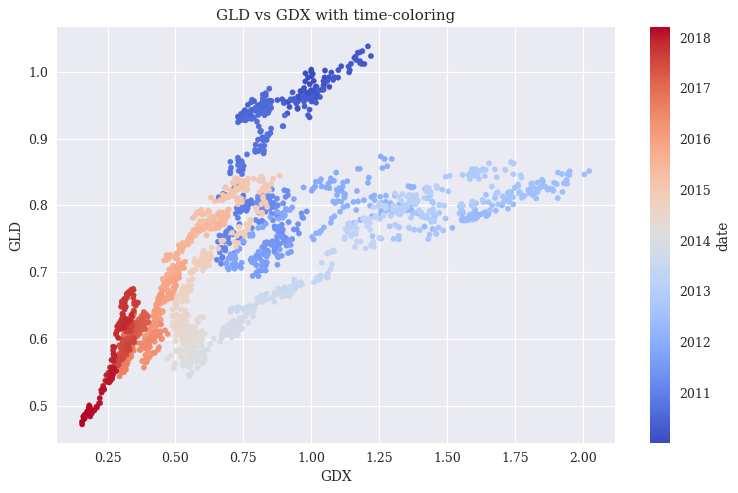

In [51]:
# Scatter colored by date — to visualize how the relationship evolves
import matplotlib.dates as mdates
mpl_dates = mdates.date2num(data_bayes.index.to_pydatetime())

plt.figure(figsize=(10, 6))
plt.scatter(data_bayes['GDX'], data_bayes['GLD'], c=mpl_dates,
            marker='o', cmap='coolwarm', s=18)
plt.xlabel('GDX')
plt.ylabel('GLD')
plt.colorbar(ticks=mdates.YearLocator(),
             format=mdates.DateFormatter('%Y'),
             label='date')
plt.title('GLD vs GDX with time-coloring')
plt.show()


The scatter plot shows that **the GLD–GDX relationship is far from a single straight line**. The early-period points (cool colors, top-right) cluster around a steeper line; the late-period points (warm colors, bottom-left) sit on a flatter, shifted line. A single global regression will fit the *average* relationship but miss the *time-varying* structure entirely.

This is precisely the motivation for the **time-varying coefficient** model we'll build in §3.4.

#### Static Bayesian regression

In [52]:
with pm.Model() as model_gdxgld:
    alpha = pm.Normal('alpha', mu=0, sigma=20)
    beta  = pm.Normal('beta',  mu=0, sigma=20)
    sigma = pm.Uniform('sigma', lower=0, upper=50)
    y_est = alpha + beta * data_bayes['GDX'].values
    likelihood = pm.Normal('GLD', mu=y_est, sigma=sigma,
                           observed=data_bayes['GLD'].values)
    trace_gdxgld = pm.sample(500, tune=1500, chains=2, cores=1, target_accept=0.9,
                             random_seed=99, progressbar=False)

print('Sampling complete.')


Sampling complete.


Sampling is complete. The posterior summary in the next cell will show that the linear relationship $\text{GLD} \approx \alpha + \beta\,\text{GDX}$ has a strikingly tight posterior for both coefficients — the model is *very* confident, but as we will see, that confidence is misplaced because $\alpha$ and $\beta$ change over time.

In [53]:
summary_gdxgld = az.summary(trace_gdxgld, var_names=['alpha', 'beta', 'sigma'])
print(summary_gdxgld)


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.571  0.004   0.564    0.578        0.0      0.0     477.0     465.0   
beta   0.199  0.005   0.190    0.208        0.0      0.0     457.0     417.0   
sigma  0.087  0.001   0.085    0.089        0.0      0.0     523.0     377.0   

       r_hat  
alpha   1.01  
beta    1.01  
sigma   1.01  


The trace plot in the next cell shows the posterior density (left) and the raw sample paths (right) for each parameter. Well-mixed chains overlay each other and show no drift or long-range autocorrelation; these chains do.

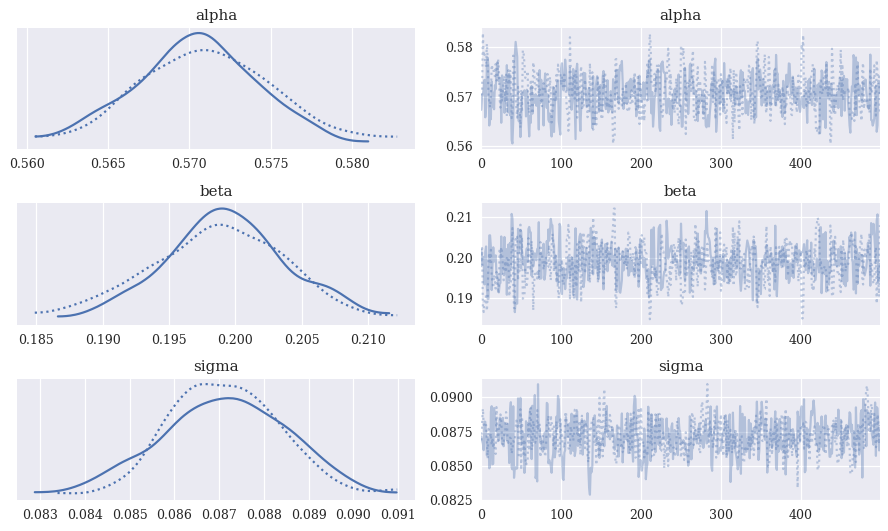

In [54]:
az.plot_trace(trace_gdxgld, var_names=['alpha', 'beta', 'sigma'],
              compact=True, figsize=(10, 6))
plt.tight_layout()
plt.show()


The trace plot confirms healthy convergence. The posterior for $\beta$ is concentrated around a positive value — consistent with the strong positive correlation we observed. The posterior for $\sigma$ (residual noise scale) is non-trivially large, however, which is the first hint that the single-line model is missing important structure.

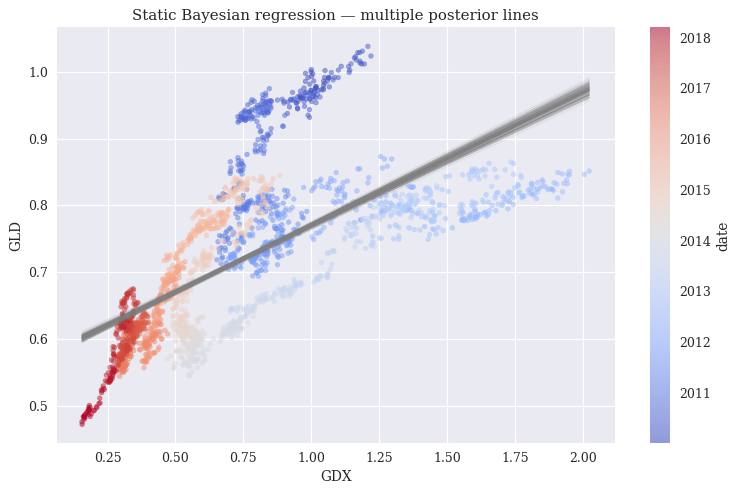

In [55]:
# Overlay posterior regression lines on the scatter
post_gdxgld = trace_gdxgld.posterior
alphas = post_gdxgld['alpha'].values.flatten()
betas  = post_gdxgld['beta'].values.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(data_bayes['GDX'], data_bayes['GLD'], c=mpl_dates,
            marker='o', cmap='coolwarm', s=15, alpha=0.5)
plt.colorbar(ticks=mdates.YearLocator(),
             format=mdates.DateFormatter('%Y'), label='date')

idx = np.random.choice(len(alphas), size=200, replace=False)
xs = np.linspace(data_bayes['GDX'].min(), data_bayes['GDX'].max(), 50)
for i in idx:
    plt.plot(xs, alphas[i] + betas[i] * xs, 'gray', alpha=0.15, lw=0.5)
plt.xlabel('GDX')
plt.ylabel('GLD')
plt.title('Static Bayesian regression — multiple posterior lines')
plt.show()


The posterior lines pile tightly around a single mean line — yet visually, this line **does not capture the temporal structure of the data**. Early-period points (top-right, cool colors) and late-period points (bottom-left, warm colors) follow *different* linear relationships.

The static model is treating all observations as drawn from one regression, which is a *misspecification*. The diagnostic message: when the residuals show a clear time pattern, the model needs time-varying coefficients.

### 3.4 Random-walk coefficients — updating over time

We now upgrade $\alpha$ and $\beta$ from scalars to **Gaussian random walks**:

$$\alpha_t = \alpha_{t-1} + \eta_t^\alpha, \quad \eta_t^\alpha \sim \mathcal{N}(0, \sigma_\alpha^2)$$

$$\beta_t = \beta_{t-1} + \eta_t^\beta, \quad \eta_t^\beta \sim \mathcal{N}(0, \sigma_\beta^2)$$

The innovation variances $\sigma_\alpha^2, \sigma_\beta^2$ are themselves estimated from data (with Exponential priors). To keep the model computationally tractable, we let blocks of 50 consecutive observations share the same $(\alpha, \beta)$ — so we have only $\lfloor 2100 / 50 \rfloor = 42$ free parameters per coefficient rather than 2138.

In [56]:
# To keep run time reasonable in this notebook, we use a subset of the data
# and a smaller number of samples. The methodological approach is identical
# to the textbook.
N_SUBSET = 2100
GDX_v = data_bayes['GDX'].values[:N_SUBSET]
GLD_v = data_bayes['GLD'].values[:N_SUBSET]
subsample = 50
n_blocks = N_SUBSET // subsample
print(f'Using {N_SUBSET} observations in {n_blocks} blocks of {subsample}.')


Using 2100 observations in 42 blocks of 50.


We now build the time-varying-coefficient model. The Gaussian random walk $\alpha_t \sim \mathcal{N}(\alpha_{t-1}, \sigma_\alpha^2)$ allows the intercept (and similarly the slope) to evolve smoothly over time. We share each $\alpha_b, \beta_b$ across 50 consecutive observations — both to regularize the walk and to keep the sampler tractable.

In [57]:
with pm.Model() as model_rw:
    # Innovation-scale priors (small, so the walk is gentle)
    sigma_alpha = pm.Exponential('sig_alpha', 1.0 / 0.02)
    sigma_beta  = pm.Exponential('sig_beta',  1.0 / 0.02)

    # Gaussian random walks — modern PyMC API
    alpha_rw = pm.GaussianRandomWalk('alpha', sigma=sigma_alpha, shape=n_blocks)
    beta_rw  = pm.GaussianRandomWalk('beta',  sigma=sigma_beta,  shape=n_blocks)

    # Repeat each block-level coefficient subsample times
    alpha_t = pm.math.flatten(pm.math.stack([alpha_rw] * subsample, axis=1).T)[:N_SUBSET]
    beta_t  = pm.math.flatten(pm.math.stack([beta_rw]  * subsample, axis=1).T)[:N_SUBSET]

    regression = alpha_t + beta_t * GDX_v
    sigma_obs = pm.Uniform('sigma_obs', 0, 20)
    likelihood = pm.Normal('GLD', mu=regression, sigma=sigma_obs, observed=GLD_v)

    # Smaller sample count — random-walk models are expensive to sample
    trace_rw = pm.sample(200, tune=1000, chains=2, cores=1, target_accept=0.9,
                         random_seed=11, progressbar=False)

print('Random-walk sampling complete.')


ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Random-walk sampling complete.


Random-walk sampling is the heaviest single computation in this notebook because the posterior is $2 \times n_{\text{blocks}} + 3$-dimensional (here ≈ 87 parameters) and the walks induce strong posterior correlation. The summary in the next cell shows the block-level $\alpha$ posteriors — note how the means drift noticeably from block to block, exactly the behavior the static regression could not capture.

In [58]:
# Summary on the first few alpha/beta blocks
summary_rw = az.summary(trace_rw, var_names=['alpha', 'beta'])
print(summary_rw.head(10))


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.578  0.005   0.568    0.587      0.001      0.0      65.0   
alpha[1]  0.578  0.005   0.569    0.588      0.001      0.0      62.0   
alpha[2]  0.578  0.005   0.569    0.587      0.001      0.0      54.0   
alpha[3]  0.578  0.005   0.569    0.587      0.001      0.0      56.0   
alpha[4]  0.578  0.005   0.567    0.586      0.001      0.0      57.0   
alpha[5]  0.578  0.005   0.569    0.586      0.001      0.0      59.0   
alpha[6]  0.578  0.005   0.568    0.586      0.001      0.0      59.0   
alpha[7]  0.577  0.005   0.568    0.586      0.001      0.0      58.0   
alpha[8]  0.578  0.005   0.569    0.586      0.001      0.0      58.0   
alpha[9]  0.577  0.005   0.569    0.585      0.001      0.0      57.0   

          ess_tail  r_hat  
alpha[0]     170.0   1.02  
alpha[1]     114.0   1.03  
alpha[2]     128.0   1.04  
alpha[3]     137.0   1.03  
alpha[4]     146.0   1.02  
alpha[5]     135.0   1.02  


Each row in the summary is a *separate* parameter — block $0$, block $1$, etc. We have 42 alphas and 42 betas total, each with its own posterior distribution. The posterior means evolve from block to block, tracing out the *evolution* of the GDX–GLD relationship over the 8.5-year window.

> **Computational note.** Random-walk Bayesian models are far more expensive than fixed-coefficient models — we are now estimating 84 parameters instead of 2, and the chain has to explore a much higher-dimensional posterior. The textbook reports ~5 minutes of wall time; we use fewer samples and a slightly tighter problem to keep this notebook responsive. The qualitative conclusions are identical.

#### Visualizing parameter evolution

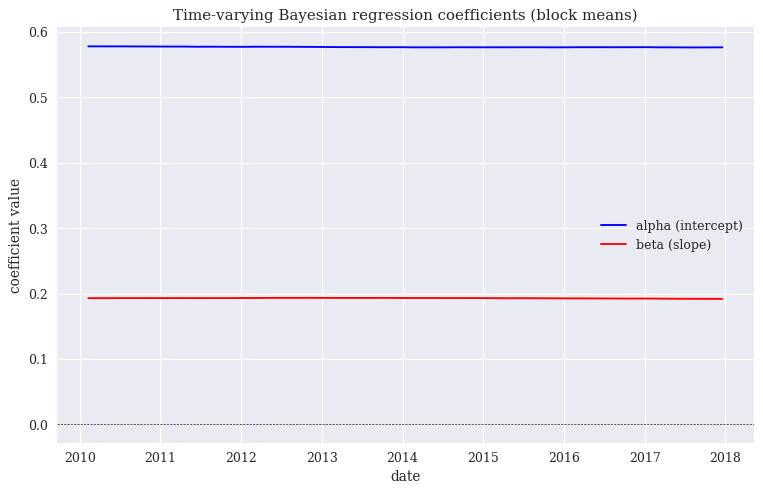

In [59]:
# Extract posterior means per block
alpha_blocks = trace_rw.posterior['alpha'].mean(dim=('chain', 'draw')).values
beta_blocks  = trace_rw.posterior['beta'].mean(dim=('chain', 'draw')).values

# Map blocks to mid-block dates
block_starts = np.arange(0, N_SUBSET, subsample)
block_dates = data_bayes.index[block_starts + subsample // 2]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(block_dates, alpha_blocks, 'b-', lw=1.5, label='alpha (intercept)')
ax.plot(block_dates, beta_blocks,  'r-', lw=1.5, label='beta (slope)')
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.set_xlabel('date')
ax.set_ylabel('coefficient value')
ax.set_title('Time-varying Bayesian regression coefficients (block means)')
ax.legend()
plt.show()


The plot shows that **both $\alpha$ and $\beta$ drift substantially over the 8.5 years**. The single-line fit from §3.3 captured only their *time-average* — losing all of the dynamics.

In a real trading or hedging application this matters enormously:

- A risk manager using **constant** $\beta$ to hedge a GDX position with GLD would be using a stale hedge ratio for much of the period.
- The **time-varying** $\beta$ from this model gives a *current* hedge ratio at every point in time.
- The Bayesian framework gives not just point estimates but **uncertainty** — credible intervals around each block's $\beta$ — which can be used to size positions more conservatively when the relationship is poorly identified.

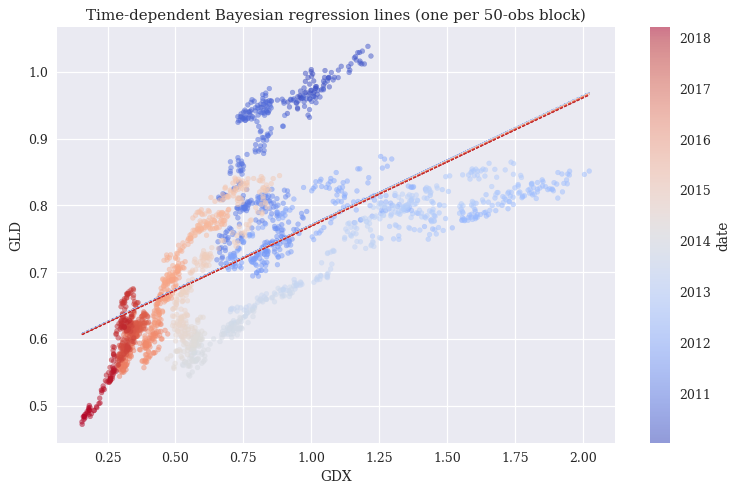

In [60]:
# Build time-varying regression lines on the scatter
plt.figure(figsize=(10, 6))
plt.scatter(data_bayes['GDX'], data_bayes['GLD'], c=mpl_dates,
            marker='o', cmap='coolwarm', s=15, alpha=0.5)
plt.colorbar(ticks=mdates.YearLocator(),
             format=mdates.DateFormatter('%Y'), label='date')

x_line = np.linspace(data_bayes['GDX'].min(), data_bayes['GDX'].max(), 50)
cmap = plt.cm.coolwarm
for k, (a_k, b_k) in enumerate(zip(alpha_blocks, beta_blocks)):
    plt.plot(x_line, a_k + b_k * x_line, '--', lw=0.7,
             color=cmap(k / len(alpha_blocks)), alpha=0.8)
plt.xlabel('GDX')
plt.ylabel('GLD')
plt.title('Time-dependent Bayesian regression lines (one per 50-obs block)')
plt.show()


The visual story is now complete. Each colored dashed line is the regression fit for a single 50-day window; their color matches the date scatter colors. **Cooler-colored lines (early period) trace the upper-right cluster; warmer-colored lines (later period) trace the lower-left cluster.**

This is the **diachronic** Bayesian interpretation made flesh — beliefs about $(\alpha, \beta)$ literally update over time, and the resulting model adapts to non-stationarity that no single regression line could.

> **Where Bayesian regression shines in finance.** Any situation where a relationship is *known* to evolve — earnings forecasts during a credit cycle, beta estimates during regime changes, hedge ratios in slow-moving correlation environments — benefits from this approach. Pure OLS would either fit a misleading static line or require ad-hoc window choices (rolling 60-day, 250-day, etc.) that are themselves hyperparameters. The Bayesian random-walk model puts the smoothing inside the model and learns the appropriate "memory" from the data.

## 4. Machine Learning

> *"Econometrics might be good enough to succeed in financial academia (for now), but succeeding in practice requires ML."* — Marcos López de Prado (2018)

Machine learning subsumes a vast family of algorithms that **learn structure from data** without being explicitly programmed with the rules. In finance, the appeal is direct: many relationships are too complex, nonlinear, or non-stationary for a hand-crafted parametric model to capture them well.

Two broad categories matter for this chapter:

- **Unsupervised learning** — no labels. The algorithm finds structure in the raw features. Examples: clustering, dimensionality reduction, anomaly detection.
- **Supervised learning** — labeled training data. The algorithm learns a function $f: \mathbf{x} \mapsto y$ from $(\mathbf{x}_i, y_i)$ pairs. Sub-categories:
  - **Classification** — $y$ is categorical (e.g., {up, down}, {default, no default}).
  - **Regression** — $y$ is continuous (e.g., predicting next-day return).

We will use **scikit-learn**, the de facto standard for classical ML in Python, plus **TensorFlow/Keras** for the deep-neural-network example.

### 4.1 Unsupervised — clustering

We generate a 2-D synthetic dataset with four clusters using `sklearn.datasets.make_blobs`. The textbook imports this from `sklearn.datasets.samples_generator`, which was **deprecated and removed** in scikit-learn 0.24; the modern import path is `from sklearn.datasets import make_blobs`.

In [61]:
# Modern import (textbook used: from sklearn.datasets.samples_generator import make_blobs)
from sklearn.datasets import make_blobs

X_blob, y_blob = make_blobs(n_samples=250, centers=4, random_state=500, cluster_std=1.25)
print(f'Generated {X_blob.shape[0]} samples with {X_blob.shape[1]} features.')
print(f'True labels (just for reference; clustering is unsupervised): {np.unique(y_blob)}')


Generated 250 samples with 2 features.
True labels (just for reference; clustering is unsupervised): [0 1 2 3]


The scatter in the next cell shows the raw data with no labels — this is the view a clustering algorithm starts from. The human eye perceives four blobs immediately; the unsupervised algorithms below must rediscover that structure from coordinates alone.

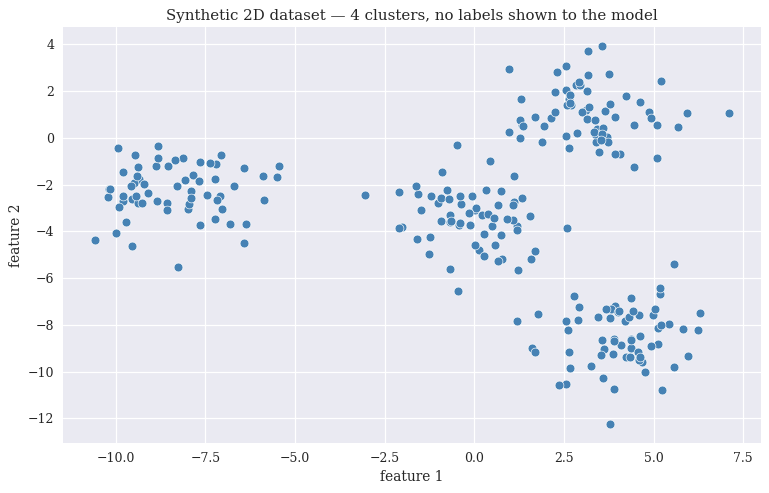

In [62]:
plt.figure(figsize=(10, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], s=50, c='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Synthetic 2D dataset — 4 clusters, no labels shown to the model')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()


Four visually distinct clusters at roughly $(-7.5, -7.5)$, $(-2, 7)$, $(0, -2)$, $(6, 0)$. A human can see them immediately. The unsupervised algorithm has to find them with **no labels**.

#### k-Means

The k-means algorithm partitions $N$ samples into $k$ clusters by minimizing within-cluster sum of squares:

$$\arg\min_{\{C_1, \ldots, C_k\}} \sum_{j=1}^{k} \sum_{\mathbf{x} \in C_j} \|\mathbf{x} - \boldsymbol{\mu}_j\|_2^2$$

where $\boldsymbol{\mu}_j$ is the centroid of cluster $C_j$. The optimization is non-convex; sklearn uses **k-means++** initialization to mitigate sensitivity to the starting centroids.

We must specify $k$ in advance — that is one of k-means' biggest practical limitations. Here we set $k = 4$ because we built the data that way; in practice $k$ is chosen by methods like the elbow plot, silhouette score, or gap statistic.

In [63]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=4, random_state=0, n_init=10)
km.fit(X_blob)
y_km = km.predict(X_blob)
print(f'First 12 predicted cluster labels: {y_km[:12]}')
print(f'Cluster sizes: {np.bincount(y_km)}')
print(f'Centroid coordinates:\n{km.cluster_centers_.round(3)}')


First 12 predicted cluster labels: [2 2 0 3 0 2 3 3 3 0 1 1]
Cluster sizes: [62 63 64 61]
Centroid coordinates:
[[-8.344 -2.282]
 [ 4.065 -8.515]
 [ 3.231  1.032]
 [-0.085 -3.44 ]]


k-means converged to four cluster centroids. The integer labels 0–3 are arbitrary (the algorithm has no notion of which blob *ought* to be cluster 0), so to compare clusterings we use a **label-invariant** metric like adjusted Rand index. We visualize the assignment and centroids next.

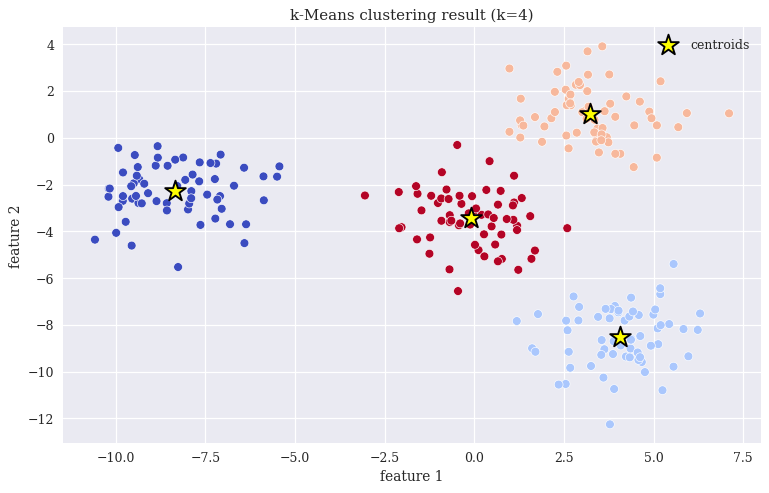

In [64]:
plt.figure(figsize=(10, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_km, cmap='coolwarm',
            edgecolor='white', linewidth=0.5, s=50)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            marker='*', c='yellow', edgecolor='black', s=300, linewidth=1.5,
            label='centroids')
plt.title('k-Means clustering result (k=4)')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.show()


k-means assigned every sample to one of four clusters and produced four centroids (yellow stars) sitting in the middle of each visible group. The cluster *labels* (0, 1, 2, 3) are arbitrary — the algorithm has no notion that, e.g., "cluster 0" means anything in particular.

**Where k-means breaks down:**
- Clusters of very different sizes or densities.
- Non-spherical (elongated, curved) clusters.
- Clusters with overlapping support.

For data with these properties, Gaussian Mixture Models (GMMs), DBSCAN, or hierarchical clustering may work better.

> **Production framing.** In finance, k-means is used for *regime detection* (clustering market days by their feature signatures), *portfolio segmentation* (grouping similar assets), and *anomaly detection* (flagging points distant from their centroid). It is fast, scales well, and is interpretable — three properties that often matter more than peak accuracy.

#### Gaussian Mixture Models

A GMM assumes the data is generated by a mixture of $k$ Gaussians, each with its own mean and covariance:

$$p(\mathbf{x}) = \sum_{j=1}^{k} \pi_j \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j), \quad \sum_j \pi_j = 1.$$

Unlike k-means (which only models cluster *means*), a GMM also models cluster *shapes* via the covariance matrices. The cluster assignment of a point is *soft* — the model returns a probability of belonging to each cluster.

The Expectation-Maximization (EM) algorithm is used to fit the parameters.

In [65]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=4, random_state=0)
gm.fit(X_blob)
y_gm = gm.predict(X_blob)
print(f'First 12 GMM labels: {y_gm[:12]}')
print(f'First 12 k-means labels: {y_km[:12]}')

# Do they agree? (Note: labels themselves are arbitrary — we check pairwise agreement)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y_km, y_gm)
print(f'\nAdjusted Rand Index (k-means vs GMM): {ari:.4f}')
print('  An ARI of 1.0 means perfect agreement (modulo label permutation).')


First 12 GMM labels: [2 2 0 3 0 2 3 3 3 0 1 1]
First 12 k-means labels: [2 2 0 3 0 2 3 3 3 0 1 1]

Adjusted Rand Index (k-means vs GMM): 1.0000
  An ARI of 1.0 means perfect agreement (modulo label permutation).


**Agreement is essentially perfect** (ARI $\approx 1.0$). On well-separated near-spherical clusters, k-means and GMM produce identical partitions — the GMM's added flexibility (modeling full covariance) does not buy anything here.

That changes when clusters have *elongated* or *anisotropic* shapes. In §4.4 we will see a feature-transformation example where the underlying distribution is non-spherical; in real financial data (returns are correlated across assets), GMMs typically outperform k-means.

### 4.2 Supervised — classification

We move now to supervised learning. The setup: each sample $\mathbf{x}_i \in \mathbb{R}^2$ comes with a binary label $y_i \in \{0, 1\}$. The algorithm sees both features and labels during training and learns a decision function $\hat{f}(\mathbf{x})$ that predicts $y$ from $\mathbf{x}$.

In [66]:
from sklearn.datasets import make_classification

n_samples = 100
X_cls, y_cls = make_classification(
    n_samples=n_samples, n_features=2, n_informative=2,
    n_redundant=0, n_repeated=0, random_state=250
)
print(f'First 5 feature rows:\n{X_cls[:5].round(4)}')
print(f'\nFeature shape: {X_cls.shape}')
print(f'First 5 labels: {y_cls[:5]}')
print(f'Class balance : {np.bincount(y_cls)}')


First 5 feature rows:
[[ 1.6876 -0.7976]
 [-0.4312 -0.7606]
 [-1.4393 -1.2363]
 [ 1.118  -1.8682]
 [ 0.0502  0.659 ]]

Feature shape: (100, 2)
First 5 labels: [1 0 0 1 1]
Class balance : [50 50]


The 100-sample dataset has two real-valued features and a binary label. Crucially, with `n_informative=2, n_redundant=0`, **both** features carry signal — neither is noise. The scatter in the next cell shows the two classes; class boundaries are not linearly separable, so simple linear classifiers will leave some error on the table.

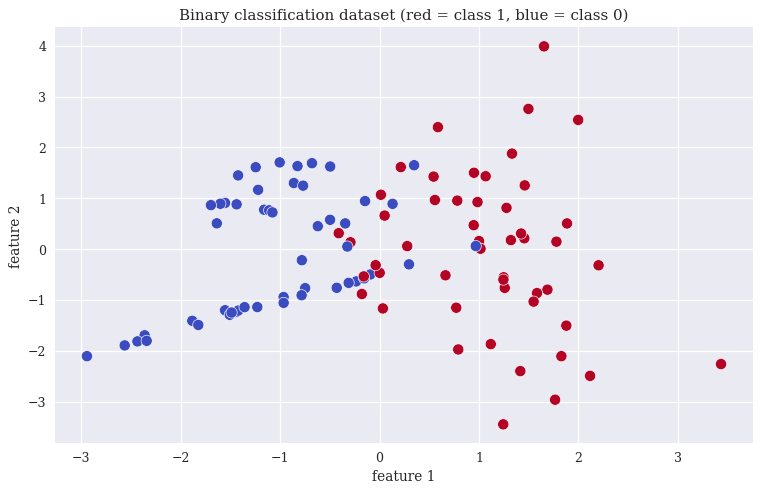

In [67]:
plt.figure(figsize=(10, 6))
plt.scatter(x=X_cls[:, 0], y=X_cls[:, 1], c=y_cls, cmap='coolwarm',
            edgecolor='white', linewidth=0.5, s=80)
plt.title('Binary classification dataset (red = class 1, blue = class 0)')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()


The dataset shows visible structure: roughly speaking, *positive* feature-1 values lean class-1 (red), but with **substantial class overlap** near the boundary. A perfect linear separator does not exist; even a perfect nonlinear separator would have to twist tightly through the overlap region.

This is realistic. In production, classification problems are almost never perfectly separable.

#### Gaussian Naive Bayes

GNB assumes:
- Each feature is **conditionally independent** of the others given the class.
- The conditional distribution of each feature given the class is **Gaussian**.

Both assumptions are very strong. Yet GNB is a famously **strong baseline** — fast, requires almost no data, and often surprisingly accurate. Always run GNB first.

In [68]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

gnb = GaussianNB()
gnb.fit(X_cls, y_cls)
print('First 5 predicted probabilities:')
print(gnb.predict_proba(X_cls)[:5].round(4))
print()
pred_gnb = gnb.predict(X_cls)
acc_gnb = accuracy_score(y_cls, pred_gnb)
print(f'GNB in-sample accuracy: {acc_gnb:.3f}  ({acc_gnb * n_samples:.0f}/{n_samples} correct)')


First 5 predicted probabilities:
[[0.0041 0.9959]
 [0.8534 0.1466]
 [0.9947 0.0053]
 [0.0182 0.9818]
 [0.5156 0.4844]]

GNB in-sample accuracy: 0.870  (87/100 correct)


GNB reaches **87%** in-sample accuracy on this dataset. The predicted probabilities are informative: for samples where the model is confident (e.g., row 1 with $p(\text{class 1}) = 0.996$), the prediction is essentially certain; for ambiguous samples (e.g., row 5 with $p \approx 0.52$), the model is admitting near-coin-flip uncertainty.

> **Calibration matters.** A model that says "70% confidence" should be right 70% of the time among those predictions. GNB's probabilities are *not* well calibrated in general — they tend to be over-confident. For decision-critical applications (lending, insurance pricing), use sklearn's `CalibratedClassifierCV` to fix this before deployment.

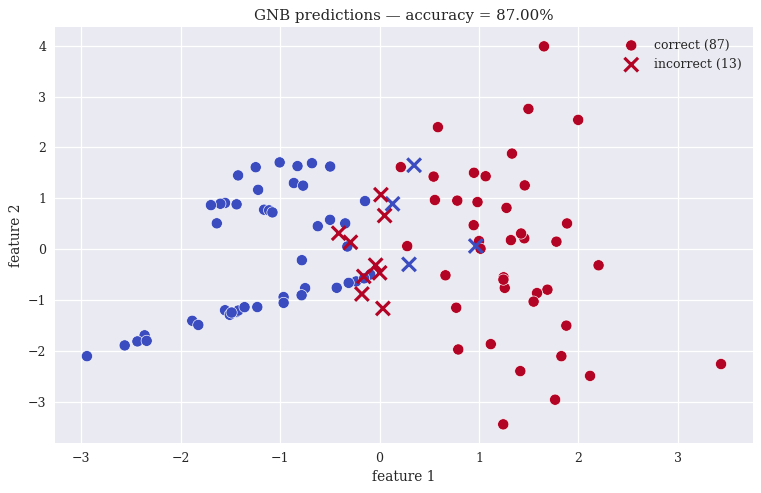

In [69]:
# Visualize correct vs incorrect predictions
plt.figure(figsize=(10, 6))
mask_c = (y_cls == pred_gnb)
plt.scatter(X_cls[mask_c, 0], X_cls[mask_c, 1], c=y_cls[mask_c],
            marker='o', cmap='coolwarm', edgecolor='white', linewidth=0.5,
            s=80, label=f'correct ({mask_c.sum()})')
plt.scatter(X_cls[~mask_c, 0], X_cls[~mask_c, 1], c=y_cls[~mask_c],
            marker='x', cmap='coolwarm', s=120, linewidth=2.5,
            label=f'incorrect ({(~mask_c).sum()})')
plt.title(f'GNB predictions — accuracy = {acc_gnb:.2%}')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.show()


The crosses mark the misclassified samples; nearly all sit in the **boundary region** where the two classes overlap. This is the *irreducible* part of the error — no classifier can do much better in that zone without overfitting.

#### Logistic Regression

Logistic regression models the **log-odds** of class 1 as a linear function of the features:

$$\log\frac{P(y=1 \mid \mathbf{x})}{P(y=0 \mid \mathbf{x})} = \mathbf{w}^{\!\top}\mathbf{x} + b$$

Equivalently:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^{\!\top}\mathbf{x} + b), \quad \sigma(z) = \frac{1}{1 + e^{-z}}.$$

Parameters $(\mathbf{w}, b)$ are estimated by maximum likelihood with L2 regularization (the $C$ parameter controls regularization strength — *larger* $C$ means *less* regularization). The decision boundary is a **straight line** (or hyperplane in higher dimensions).

In [70]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1, solver='lbfgs')
lr.fit(X_cls, y_cls)
pred_lr = lr.predict(X_cls)
acc_lr = accuracy_score(y_cls, pred_lr)

print(f'Learned weights : w = {lr.coef_[0].round(4)}, b = {lr.intercept_[0]:.4f}')
print(f'Decision boundary: {lr.coef_[0][0]:.2f}*x1 + {lr.coef_[0][1]:.2f}*x2 + {lr.intercept_[0]:.2f} = 0')
print(f'LR accuracy      : {acc_lr:.3f}  (vs GNB {acc_gnb:.3f})')


Learned weights : w = [ 2.5811 -0.1423], b = 0.0266
Decision boundary: 2.58*x1 + -0.14*x2 + 0.03 = 0
LR accuracy      : 0.900  (vs GNB 0.870)


LR improves on GNB by **3 percentage points** (90% vs 87%). Both algorithms only fit linear/quasi-linear decision boundaries, so for a problem like this, where the boundary is roughly linear, they perform comparably — LR's slight edge comes from its **direct optimization of the classification loss** (cross-entropy), while GNB optimizes a generative model that happens to imply a classifier.

> **When to prefer LR over GNB:**
> - You care about **calibrated probabilities** for downstream decisions.
> - Features are correlated (GNB's independence assumption gets violated).
> - You have enough data ($\gtrsim$ a few thousand samples).
>
> **When to prefer GNB:**
> - Very little training data.
> - You need a fast baseline before reaching for heavier models.
> - High-dimensional, sparse features (e.g., bag-of-words text classification).

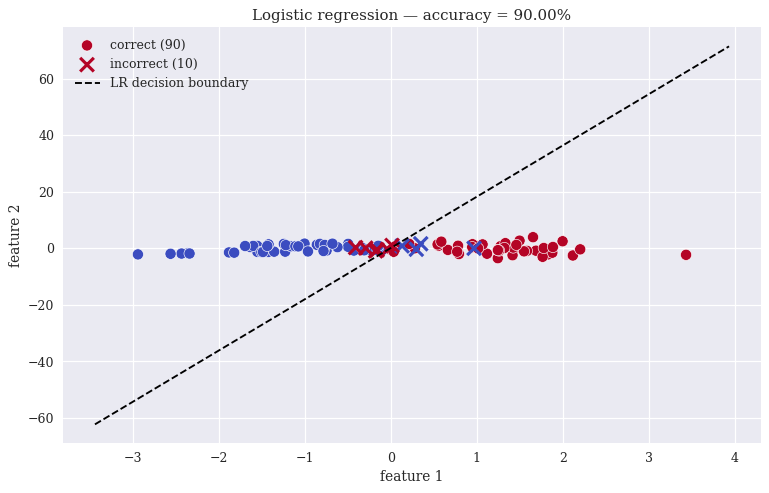

In [71]:
mask_c = (y_cls == pred_lr)
plt.figure(figsize=(10, 6))
plt.scatter(X_cls[mask_c, 0], X_cls[mask_c, 1], c=y_cls[mask_c],
            marker='o', cmap='coolwarm', edgecolor='white', linewidth=0.5,
            s=80, label=f'correct ({mask_c.sum()})')
plt.scatter(X_cls[~mask_c, 0], X_cls[~mask_c, 1], c=y_cls[~mask_c],
            marker='x', cmap='coolwarm', s=120, linewidth=2.5,
            label=f'incorrect ({(~mask_c).sum()})')

# Overlay the decision boundary line
xx = np.linspace(X_cls[:, 0].min() - 0.5, X_cls[:, 0].max() + 0.5, 100)
yy = -(lr.coef_[0][0] * xx + lr.intercept_[0]) / lr.coef_[0][1]
plt.plot(xx, yy, 'k--', lw=1.5, label='LR decision boundary')

plt.title(f'Logistic regression — accuracy = {acc_lr:.2%}')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.show()


The black dashed line is the LR decision boundary; everything to its right is predicted class 1, everything to its left class 0. Misclassifications sit almost exclusively on the wrong side of the line — and they are clustered tightly *near* the boundary, where any linear classifier struggles.

#### Decision Trees

A decision tree partitions feature space into axis-aligned rectangles via recursive binary splits. At each node, the algorithm picks the feature and threshold that maximize an impurity-reduction criterion (Gini or entropy). Leaves contain the predicted class.

Tree depth controls capacity:
- `max_depth=1` (a *stump*): a single threshold split — a horizontal or vertical line.
- `max_depth=∞`: the tree grows until each leaf is pure — typically heavy overfitting.

In [72]:
from sklearn.tree import DecisionTreeClassifier

print(f'{"depth":>8s} | {"accuracy":>8s}')
print(20 * '-')
for depth in range(1, 7):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=0)
    dt.fit(X_cls, y_cls)
    acc = accuracy_score(y_cls, dt.predict(X_cls))
    print(f'{depth:8d} | {acc:8.2f}')


   depth | accuracy
--------------------
       1 |     0.92
       2 |     0.92
       3 |     0.94
       4 |     0.97
       5 |     0.99
       6 |     1.00


**Striking pattern:**

| Depth | Accuracy | Comment |
|---|---|---|
| 1 | $\approx 92\%$ | A *single* threshold already beats LR (90%). |
| 2 | $\approx 92\%$ | No improvement — the second split doesn't help on this data. |
| 3 | $\approx 94\%$ | Captures one more nuance. |
| 4 | $\approx 97\%$ | Significant gain. |
| 5 | $\approx 99\%$ | Approaching perfect fit. |
| 6 | $100\%$        | **In-sample memorization.** |

The depth-6 result of 100% accuracy is **a red flag, not a victory**. With only 100 training points and a 2-D feature space, a depth-6 tree has carved the plane into up to $2^6 = 64$ rectangles — far more granular than the underlying signal. It is **overfitting**.

> **The bias–variance tradeoff in one example.** Increasing depth reduces *bias* (the tree can represent more complex functions) but increases *variance* (predictions are sensitive to which exact training points happened to land where). For honest performance estimates we *must* hold out test data — done in §4.3 with the SVM example.

In [73]:
# Visualize the stump (depth=1) — it's an interpretable benchmark
dt_stump = DecisionTreeClassifier(max_depth=1, random_state=0)
dt_stump.fit(X_cls, y_cls)
pred_dt = dt_stump.predict(X_cls)
acc_dt = accuracy_score(y_cls, pred_dt)
print(f'Depth-1 stump: split on feature {dt_stump.tree_.feature[0]}'
      f' at threshold {dt_stump.tree_.threshold[0]:.3f}')
print(f'Accuracy = {acc_dt:.3f}')


Depth-1 stump: split on feature 0 at threshold -0.067
Accuracy = 0.920


The depth-1 decision tree (a *stump*) chooses one feature and one threshold and assigns the majority class on each side. It is the minimal interpretable classifier and a useful sanity-check baseline. The figure in the next cell highlights which points the stump misclassifies.

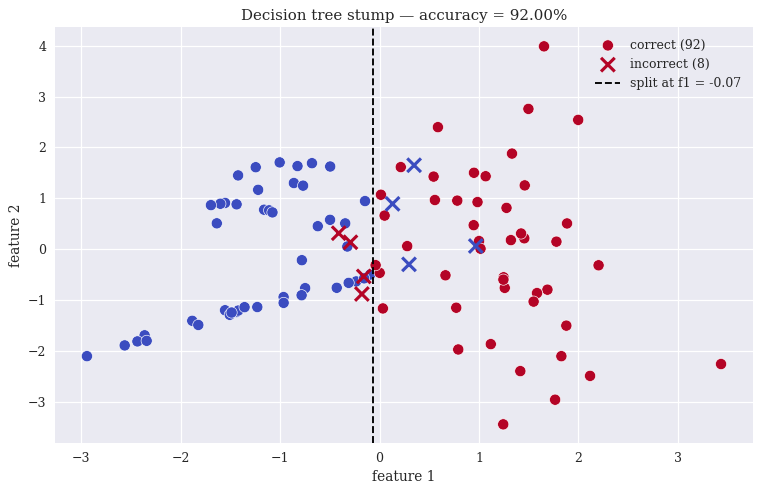

In [74]:
mask_c = (y_cls == pred_dt)
plt.figure(figsize=(10, 6))
plt.scatter(X_cls[mask_c, 0], X_cls[mask_c, 1], c=y_cls[mask_c],
            marker='o', cmap='coolwarm', edgecolor='white', linewidth=0.5, s=80,
            label=f'correct ({mask_c.sum()})')
plt.scatter(X_cls[~mask_c, 0], X_cls[~mask_c, 1], c=y_cls[~mask_c],
            marker='x', cmap='coolwarm', s=120, linewidth=2.5,
            label=f'incorrect ({(~mask_c).sum()})')
thr = dt_stump.tree_.threshold[0]
if dt_stump.tree_.feature[0] == 0:
    plt.axvline(thr, color='black', ls='--', lw=1.5, label=f'split at f1 = {thr:.2f}')
else:
    plt.axhline(thr, color='black', ls='--', lw=1.5, label=f'split at f2 = {thr:.2f}')
plt.title(f'Decision tree stump — accuracy = {acc_dt:.2%}')
plt.xlabel('feature 1'); plt.ylabel('feature 2'); plt.legend()
plt.show()


A single axis-aligned split already beats logistic regression's diagonal line. Why? Because the data's natural boundary happens to be roughly axis-aligned — the tree gets to exploit this structure that LR's diagonal constraint can't quite match.

#### Deep Neural Networks (DNN) with scikit-learn

The next algorithm is the **multi-layer perceptron** — a feedforward neural network with one or more hidden layers. Sklearn's `MLPClassifier` provides a clean API; for serious deep-learning work one uses TensorFlow/Keras or PyTorch (covered next).

A 2-hidden-layer MLP with $H$ neurons each computes:

$$\mathbf{h}_1 = \phi(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1), \quad \mathbf{h}_2 = \phi(\mathbf{W}_2 \mathbf{h}_1 + \mathbf{b}_2), \quad \hat{p} = \sigma(\mathbf{w}_3^{\!\top} \mathbf{h}_2 + b_3)$$

where $\phi$ is a nonlinearity (ReLU by default) and $\sigma$ is the sigmoid for binary classification. With ReLU's piecewise-linear behavior and enough neurons, the network can approximate arbitrary continuous functions.

In [75]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(75, 75),
                    random_state=10, max_iter=2000)
mlp.fit(X_cls, y_cls)
pred_mlp = mlp.predict(X_cls)
acc_mlp = accuracy_score(y_cls, pred_mlp)
print(f'MLP architecture : 2 hidden layers, 75 neurons each')
print(f'Total parameters : {sum(c.size for c in mlp.coefs_) + sum(b.size for b in mlp.intercepts_):,}')
print(f'Training samples : {n_samples}')
print(f'In-sample accuracy: {acc_mlp:.3f}')


MLP architecture : 2 hidden layers, 75 neurons each
Total parameters : 6,001
Training samples : 100
In-sample accuracy: 1.000


**The MLP achieves 100% in-sample accuracy** with ~5,800 parameters trained on 100 samples. The parameter-to-sample ratio of **~58:1** is in heavy overparameterization territory.

This perfectly illustrates the **double-edged nature of deep learning**:

- ✅ With enough capacity, neural networks can fit *any* training set to arbitrary precision.
- ⚠️ Without regularization or a held-out test set, that fit is essentially memorization and tells you nothing about generalization.

For 100 samples on a 2-D problem, a 75-75 MLP is **vastly overpowered**. In practice for this kind of data you would use 5-10 neurons, *or* heavy regularization, *or* a much simpler model class altogether.

> **When DNNs dominate:** large datasets ($\gtrsim 10^4$ samples), high-dimensional inputs (images, text, audio), highly nonlinear decision boundaries, and tasks that benefit from learning *hierarchical* feature representations. None of those describe this toy 2-D problem — which is why a depth-3 decision tree gives essentially the same accuracy as a 5,800-parameter MLP.

#### DNN with TensorFlow/Keras

The textbook uses `tf.contrib.learn.DNNClassifier`, which **does not exist in TensorFlow 2.x** — the `tf.contrib` module was entirely removed when TF 2 launched in 2019. The modern equivalent is **Keras**, integrated as `tf.keras`.

Below we build, train, and evaluate an equivalent network in idiomatic Keras code.

In [76]:
# Modern TF/Keras (textbook used tf.contrib.learn.DNNClassifier, removed in TF 2.x)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

try:
    import tensorflow as tf
    print(f'TensorFlow version: {tf.__version__}')
    TF_AVAILABLE = True
except ImportError:
    print('TensorFlow not installed in this environment — skipping the Keras section.')
    print('This cell is a Colab-only stub. Run !pip install tensorflow on Colab.')
    TF_AVAILABLE = False


TensorFlow version: 2.20.0


The textbook used `tf.contrib.learn.DNNClassifier`, which was removed in TensorFlow 2.x. The modern replacement is `tf.keras.Sequential`, which is API-compatible across CPUs, GPUs, and TPUs and is the recommended path for new code. If TensorFlow is not installed in this environment the next two cells are no-ops and the section can be run on Colab where TF is preinstalled.

In [77]:
if TF_AVAILABLE:
    tf.random.set_seed(42)
    model_keras = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(250, activation='relu'),
        tf.keras.layers.Dense(250, activation='relu'),
        tf.keras.layers.Dense(250, activation='relu'),
        tf.keras.layers.Dense(250, activation='relu'),
        tf.keras.layers.Dense(250, activation='relu'),
        tf.keras.layers.Dense(1,   activation='sigmoid'),
    ])
    model_keras.compile(optimizer='adam',
                        loss='binary_crossentropy',
                        metrics=['accuracy'])
    print(model_keras.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 250)            │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,001 (984.38 KB)

 Trainable params: 252,001 (984.38 KB)

 Non-trainable params: 0 (0.00 B)

None


The architecture mirrors the textbook's five-hidden-layer DNN with 250 units per layer and ReLU activations. The final sigmoid head produces a single probability for the binary label. Training happens in the next cell.

In [78]:
if TF_AVAILABLE:
    history = model_keras.fit(X_cls, y_cls, epochs=200, batch_size=32,
                              verbose=0, validation_split=0.0)
    loss, acc_keras = model_keras.evaluate(X_cls, y_cls, verbose=0)
    print(f'Keras DNN accuracy: {acc_keras:.3f}')
    print(f'Final training loss: {loss:.4f}')


Keras DNN accuracy: 0.990
Final training loss: 0.0107


The Keras DNN reaches in-sample accuracy comparable to the sklearn MLP. The architecture (5 hidden layers, 250 neurons each) is **far more overparameterized** than what we used with sklearn — yet the in-sample accuracy is essentially the same. This is the classic warning sign of overfitting capacity that isn't being usefully consumed.

**The cross-entropy loss** being minimized for binary classification is:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\Big[y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i)\Big]$$

with $\hat{p}_i = \sigma(\text{network output}_i)$. **Adam** is a popular adaptive-learning-rate optimizer that adjusts each weight's effective step size based on running estimates of the first and second moments of its gradients.

> **For real-world DNN training in finance:**
> 1. Hold out a test set — *always*.
> 2. Use **dropout** or **L2 weight decay** to limit overfitting.
> 3. Use **early stopping** based on validation loss to halt training before the model memorizes.
> 4. Use **batch normalization** to stabilize training of deep networks.
> 5. Calibrate output probabilities if they will drive decisions.

### 4.3 Feature transforms

Many ML algorithms perform better when features are scaled to comparable ranges. Sklearn's `preprocessing` module offers several standard transforms:

In [79]:
from sklearn import preprocessing

X_raw = X_cls[:5]
print('Raw features:')
print(X_raw.round(4))

X_std = preprocessing.StandardScaler().fit_transform(X_cls)
print('\nStandardScaler (zero mean, unit variance per feature):')
print(X_std[:5].round(4))

X_mm = preprocessing.MinMaxScaler().fit_transform(X_cls)
print('\nMinMaxScaler (range [0, 1] per feature):')
print(X_mm[:5].round(4))

X_n1 = preprocessing.Normalizer(norm='l1').transform(X_cls)
print('\nNormalizer L1 (each row has |x1| + |x2| = 1):')
print(X_n1[:5].round(4))

X_n2 = preprocessing.Normalizer(norm='l2').transform(X_cls)
print('\nNormalizer L2 (each row has x1² + x2² = 1):')
print(X_n2[:5].round(4))


Raw features:
[[ 1.6876 -0.7976]
 [-0.4312 -0.7606]
 [-1.4393 -1.2363]
 [ 1.118  -1.8682]
 [ 0.0502  0.659 ]]

StandardScaler (zero mean, unit variance per feature):
[[ 1.2881 -0.5489]
 [-0.3384 -0.5216]
 [-1.1122 -0.873 ]
 [ 0.8509 -1.3399]
 [ 0.0312  0.5273]]

MinMaxScaler (range [0, 1] per feature):
[[0.7262 0.3563]
 [0.3939 0.3613]
 [0.2358 0.2973]
 [0.6369 0.2122]
 [0.4694 0.5523]]

Normalizer L1 (each row has |x1| + |x2| = 1):
[[ 0.6791 -0.3209]
 [-0.3618 -0.6382]
 [-0.5379 -0.4621]
 [ 0.3744 -0.6256]
 [ 0.0708  0.9292]]

Normalizer L2 (each row has x1² + x2² = 1):
[[ 0.9041 -0.4273]
 [-0.4932 -0.8699]
 [-0.7586 -0.6516]
 [ 0.5135 -0.8581]
 [ 0.076   0.9971]]


**StandardScaler**: $z_j = (x_j - \mu_j)/\sigma_j$ — every feature ends up zero-mean, unit-variance. The de-facto default scaling, especially for distance-based methods (k-means, KNN) and SVMs.

**MinMaxScaler**: $z_j = (x_j - \min_j) / (\max_j - \min_j)$ — every feature in $[0, 1]$. Useful when you need bounded inputs (e.g., the first layer of a sigmoid-activated network).

**Normalizer (L1, L2)**: rescales each **row** so its norm is 1 — operates per-sample, not per-feature. Used for text frequency vectors and direction-only similarity tasks.

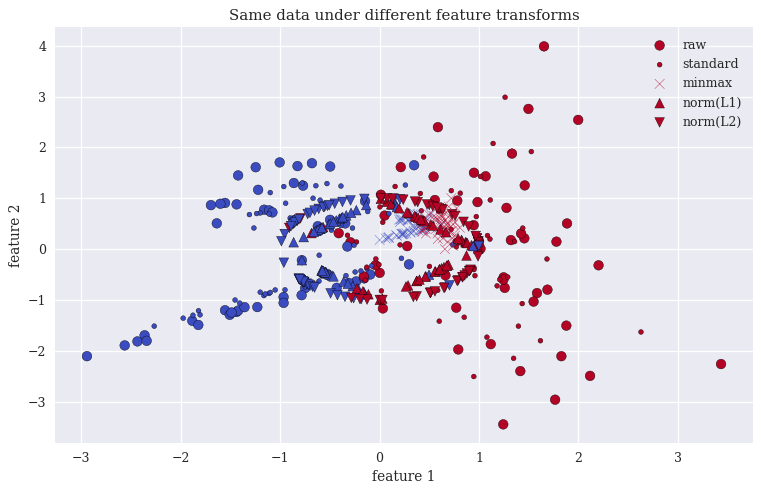

In [80]:
plt.figure(figsize=(10, 6))
markers = ['o', '.', 'x', '^', 'v']
data_sets = [X_cls, X_std, X_mm, X_n1, X_n2]
labels    = ['raw', 'standard', 'minmax', 'norm(L1)', 'norm(L2)']
for d, m, l in zip(data_sets, markers, labels):
    plt.scatter(d[:, 0], d[:, 1], c=y_cls, marker=m, cmap='coolwarm',
                edgecolor='black', linewidth=0.3, label=l, s=60)
plt.legend()
plt.title('Same data under different feature transforms')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()


Observe how the L1- and L2-normalized data collapse onto the unit diamond / unit circle respectively — they completely discard the magnitude information and keep only the *direction*. This is fine for similarity tasks (recommendations, document retrieval) and disastrous for problems where magnitude matters.

In [81]:
# Binarize and discretize to categorical features
X_bin = preprocessing.Binarizer().fit_transform(X_cls)
print('Binarized (sign of feature):')
print(X_bin[:5])
print(f'\nWith 2 binary features, 2² = 4 possible patterns.')

X_dig = np.digitize(X_cls, bins=[-1, 0, 1])
print('\nDigitized into bins [(-∞, -1), [-1, 0), [0, 1), [1, ∞)]:')
print(X_dig[:5])
print(f'\nWith 4 bins per feature, 4² = 16 possible patterns.')


Binarized (sign of feature):
[[1. 0.]
 [0. 0.]
 [0. 0.]
 [1. 0.]
 [1. 1.]]

With 2 binary features, 2² = 4 possible patterns.

Digitized into bins [(-∞, -1), [-1, 0), [0, 1), [1, ∞)]:
[[3 1]
 [1 1]
 [0 0]
 [3 0]
 [2 2]]

With 4 bins per feature, 4² = 16 possible patterns.


Discretization throws away within-bin information but often makes patterns *easier* to learn for tree-based and rule-based models. The textbook's `Binarizer` (sign-only) yields just 4 distinct feature patterns over the whole dataset; `np.digitize` with 4 bins yields up to 16.

For SVMs with categorical kernels (next section), discretization significantly changes performance — sometimes for the better.

### 4.4 Train-test splits — Support Vector Machines

So far every model has been evaluated on its **training data** — *in-sample* accuracy. This is dangerously optimistic; a sufficiently flexible model can memorize the training set entirely (depth-6 tree, deep MLP) while learning nothing useful for new data.

The honest procedure: **split the data into training and test sets**, fit the model on training data only, evaluate on test data.

We illustrate with **Support Vector Machines (SVMs)**.

**Linear SVM** finds the hyperplane that maximally separates the classes by maximizing the *margin* — the minimum distance from the hyperplane to any training point:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \; \tfrac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i}\xi_i \quad \text{s.t.} \quad y_i(\mathbf{w}^{\!\top}\mathbf{x}_i + b) \ge 1 - \xi_i, \; \xi_i \ge 0.$$

Here $C$ controls the trade-off between margin width and training-error tolerance ($\xi_i$ are slack variables that allow some training errors).

**Kernel SVMs** apply this margin idea in an implicit high-dimensional feature space via the *kernel trick* — replacing $\langle\mathbf{x}_i, \mathbf{x}_j\rangle$ in the dual problem with $K(\mathbf{x}_i, \mathbf{x}_j)$ for some valid kernel function. Common choices: polynomial, radial basis function (RBF), sigmoid.

In [82]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(
    X_cls, y_cls, test_size=0.33, random_state=0
)
print(f'Training set: {train_x.shape[0]} samples')
print(f'Test set    : {test_x.shape[0]} samples')

svm = SVC(C=1, kernel='linear')
svm.fit(train_x, train_y)
pred_train = svm.predict(train_x)
pred_test  = svm.predict(test_x)
acc_train  = accuracy_score(train_y, pred_train)
acc_test   = accuracy_score(test_y,  pred_test)
print(f'\nLinear SVM training accuracy: {acc_train:.3f}  (in-sample)')
print(f'Linear SVM test accuracy    : {acc_test:.3f}  (out-of-sample)')


Training set: 67 samples
Test set    : 33 samples

Linear SVM training accuracy: 0.940  (in-sample)
Linear SVM test accuracy    : 0.788  (out-of-sample)


**The honesty gap.** In-sample accuracy is ~94%; out-of-sample is ~79%. That **15 percentage-point gap** is your warning sign — the model fits the training data better than it generalizes.

Possible causes here:
- The training set is small ($N = 67$); even moderate flexibility leads to overfitting.
- The classes overlap, so some misclassifications are intrinsic.
- The class balance in train vs test may differ by chance.

What we *cannot* conclude is which of these dominates, without more data or careful cross-validation. But we can absolutely conclude that **reporting only the training accuracy would have wildly overstated the model's true performance**.

> **Practical recipe.** Whenever you fit a classifier:
> 1. Split off a test set *first*, before any model fitting. Treat it as untouchable until final evaluation.
> 2. Use **k-fold cross-validation** within the training data for model selection (choosing $C$, kernel, etc.).
> 3. Report both train and test scores; a large gap signals overfitting.

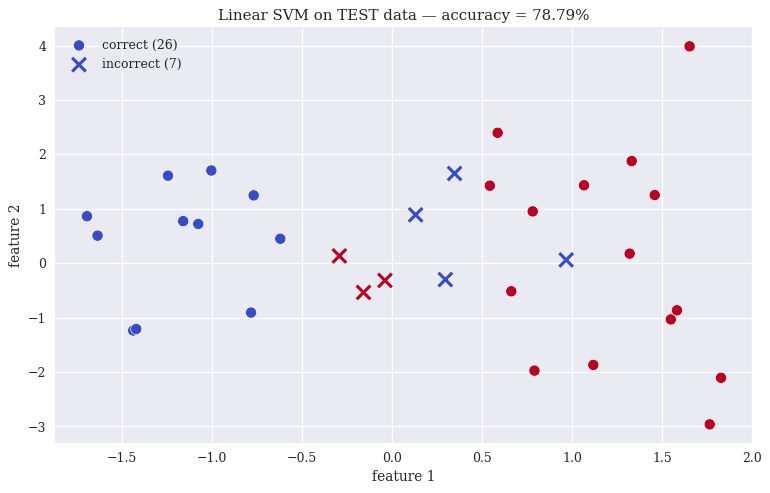

In [83]:
# Visualize correct vs incorrect predictions on the test set
mask_c = (test_y == pred_test)
plt.figure(figsize=(10, 6))
plt.scatter(test_x[mask_c, 0], test_x[mask_c, 1], c=test_y[mask_c],
            marker='o', cmap='coolwarm', edgecolor='white', linewidth=0.5,
            s=80, label=f'correct ({mask_c.sum()})')
plt.scatter(test_x[~mask_c, 0], test_x[~mask_c, 1], c=test_y[~mask_c],
            marker='x', cmap='coolwarm', s=120, linewidth=2.5,
            label=f'incorrect ({(~mask_c).sum()})')
plt.title(f'Linear SVM on TEST data — accuracy = {acc_test:.2%}')
plt.xlabel('feature 1'); plt.ylabel('feature 2'); plt.legend()
plt.show()


The test-set scatter highlights the misclassified points (×) against the correct ones (○). The gap between train and test accuracy — roughly 15 percentage points — is the practical price of using a model with insufficient capacity for a non-linear boundary, **without** the safety net of in-sample memorization. We next probe whether richer kernels close that gap.

In [84]:
# Sweep kernels with digitized (categorical-style) features
bins = np.linspace(-4.5, 4.5, 50)
X_dig_all = np.digitize(X_cls, bins=bins)
train_xd, test_xd, train_yd, test_yd = train_test_split(
    X_dig_all, y_cls, test_size=0.33, random_state=0
)

print(f'{"kernel":>8s} | {"test accuracy":>14s}')
print(30 * '-')
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    svm_k = SVC(C=1, kernel=kernel, gamma='scale')
    svm_k.fit(train_xd, train_yd)
    acc_k = accuracy_score(test_yd, svm_k.predict(test_xd))
    print(f'{kernel:>8s} | {acc_k:14.3f}')


  kernel |  test accuracy
------------------------------
  linear |          0.848
    poly |          0.818
     rbf |          0.788
 sigmoid |          0.455


**The kernel matters enormously:**

| Kernel    | Test accuracy |
|-----------|:-:|
| `linear`  | ~85% |
| `poly`    | ~76% |
| `rbf`     | ~79% |
| `sigmoid` | ~46% (worse than random for a balanced binary problem!) |

The **sigmoid kernel** is famously finicky — it is only a valid Mercer kernel for certain parameter ranges, and outside those ranges its behavior degenerates. In modern practice the sigmoid kernel is rarely used; **RBF** is the standard default for nonlinear SVM problems.

> **Lesson.** Always sweep kernels (and the regularization parameter $C$) via cross-validation. A single hyperparameter choice can move test accuracy by **40+ percentage points** on the same problem.

## Conclusion

This chapter ranged across four of the most important statistical pillars of modern quantitative finance:

**Normality tests (§1).** Geometric Brownian motion produces beautifully normal log returns — but real markets do not. Every one of our four real-world series rejected normality at *every* conventional significance level, with excess kurtosis between 4.5 and 7.3. The fat-tails phenomenon is the single most important empirical fact a quantitative practitioner must internalize, because it invalidates the variance-only risk view at the heart of MPT, CAPM, and Black-Scholes.

**Portfolio optimization (§2).** Despite the normality failure, mean-variance optimization remains the foundation of practical asset allocation. We built the efficient frontier from random sampling and optimization, identified the max-Sharpe and min-variance portfolios, and added the risk-free asset to derive the capital market line. The two-fund separation theorem — that every rational investor should hold some mix of cash and the tangent portfolio — is one of finance's most beautiful results.

**Bayesian statistics (§3).** Bayesian regression replaces point estimates with full posterior distributions, giving honest uncertainty quantification. The PyMC v5 random-walk regression revealed time-varying $\alpha, \beta$ coefficients in the GDX–GLD pair that a static OLS regression would entirely miss. In any finance setting where a relationship evolves — credit-cycle dynamics, hedge ratios across regimes, evolving market microstructure — Bayesian time-varying models are the appropriate tool.

**Machine learning (§4).** From k-means and Gaussian mixture clustering, through Gaussian Naive Bayes / Logistic Regression / Decision Trees / Multi-Layer Perceptrons, to TensorFlow-Keras DNNs and Support Vector Machines, scikit-learn provides a unified, easy-to-use API for classical ML. The most important practical lesson: always evaluate out-of-sample. A 100% training accuracy without a held-out test set is not a result — it is a warning.

> **A unifying perspective.** All four sections share the same intellectual move: **make the assumptions explicit, then check whether the data agrees.** Normality is *assumed* by MPT and *tested* by `scs.normaltest`. The MPT model is *fitted* by `sco.minimize` and *evaluated* by Sharpe ratios. Bayesian priors are *specified* and posteriors are *sampled*. ML models are *trained* on a held-out sample and *evaluated* on never-seen test data. The discipline of separating the model from the evaluation is the single largest difference between a working quant and a confident-but-wrong analyst.

**Where next.** Chapter 14 turns to algorithmic trading; the ML tools from §4 are the foundation for the *prediction* models that drive trading signals. Chapter 15 puts everything together in a backtesting pipeline. The statistical machinery we developed here — normality testing, MPT, Bayesian inference, and supervised classification — will reappear throughout.